<a href="https://colab.research.google.com/github/brewburgr/Nucleosome/blob/master/Experimental_evaluation_surface_method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#import

In [2]:
!pip install uv
!uv pip install pyshtools
!uv pip install plyfile
!uv pip install pyvista

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 24.0 MB/s eta 0:00:00
Using Python 3.12.12 environment at: /usr
Resolved 31 packages in 409ms
Prepared 2 packages in 286ms
Installed 2 packages in 6ms
 + boule==0.5.0
 + pyshtools==4.14.1
Using Python 3.12.12 environment at: /usr
Resolved 2 packages in 94ms
Prepared 1 package in 17ms
Installed 1 package in 1ms
 + plyfile==1.1.3
Using Python 3.12.12 environment at: /usr
Resolved 31 packages in 199ms
Prepared 4 packages in 2.83s
Installed 4 packages in 35ms
 + cyclopts==4.10.0
 + pyvista==0.47.1
 + rich-rst==1.3.2
 + vtk==9.6.0


In [18]:
# @title imports
import numpy as np
import numba
import scipy.integrate
import scipy.special
import scipy.spatial
from scipy.interpolate import RegularGridInterpolator
import os
import numpy.polynomial.legendre as leg
from matplotlib import ticker as tck
import matplotlib as mpl
from datetime import datetime, date
from google.colab import drive
import scipy.io as sio
import matplotlib.patches as patches
import pandas as pd
import tifffile as tif
import scipy as sp
import scipy.sparse as spm
from scipy.sparse.linalg import lsqr, spsolve
from scipy.interpolate import RectBivariateSpline
from scipy.optimize import minimize, Bounds, brute, approx_fprime
from scipy.io import loadmat, savemat

from plyfile import PlyData, PlyElement
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import sys, time, os.path
from itertools import permutations
import pyshtools as _psh
import pyshtools





codepath='/content/drive/MyDrive/Drive_Masterarbeit/Module'
import sys
sys.path.append(codepath)


from helper_functions import (
    rts, nu, E, distance, lame_mu, lame_lambda,
    vector_sph_to_cart, vector_cart_to_sph, cart_to_sph_coords,
    all_errors_2D_old, AAD_surface, all_errors_2D,
    full5tap3D, full9tap3D, set_axes_equal, visSH3D_data3,
    extendflip, generate_submat, loadCoeffs,
)
from indentation_profiles import Axialsymmetric, ringxygausszz, indentergausszz, Hertzian_contact
from shelastic.shutil import SphCoord_to_CartCoord, CartCoord_to_SphCoord, GLQCartCoord
from shelastic.shutil import SHCilmToVector, SHVectorToCilm, SHVec2mesh, SHmesh2Vec
from shelastic.shutil import TransMat, l_coeffs, m_coeffs, LM_list, lmk2K, K2lmk
from shelastic.shbv   import generate_submat, Uvec2Tvec, Tvec2Uvec
from shelastic.shvis  import plotfv, vismesh, visSHVec, visSH3d
from shelastic.sphere_utils import loadCoeffs, arbitrary_force, Ur_interp
from shelastic.sphere_utils import usurf2umesh, dumesh_dus, usurf2vec, usurf2dr
from shelastic.sphere_utils import Tvec2Tres, usurf2dr2, calculateTfv, genSmat, genLmat, grad_usurf2dr2

# MF multiple for actual magnitude...

In [7]:
############################# change inputs here #################################
# Data file name
shapename = 'noise'
E0=1500; nu0 = 0.4 ;
# Material properties
mu0 = lame_mu(E0, nu0);
print(mu0)
r0 = 12;           # microns


# Spherical Harmonics Analysis Settings
lJmax = 20; lKmax = lJmax; lmax_plot = 60;
lmax_gen=200
noise_level=0

# initial guess settings
init_guess_type = 'ur-only' #'ur-only' or 'true'

# regularizations
myalpha = 1     # traction magnitude
mybeta  = 1  # coefficient magnitude
mygamma = 0.3   # anti-aliasing parameter     (beta  in the paper)

# program switches
plot_figure = True
savefig = False
myord = 1; # myord: p-norm order (1-mean value)

# minimization settings
maxiter_per_period = 20
CG_gtol = 1e-7          # This determines how good we want the analysis to be
eps = 1e-4              # for jacobian

minimizer = 'CG'
minimizer_config = {'maxiter': maxiter_per_period, 'disp': True, 'gtol': CG_gtol}

# dump files for minimization
savename = shapename + ('_b%.0f_n%.1e_lmax%d'%(mybeta, noise_level, lJmax))


535.7142857142858


In [10]:
#@title Functions

import time

def prep_run():
    target_args = (f_interp, lJmax, mybeta, myord, X0surf, X0, isTfv, Cmat, Dmat,
               mu0, nu0, np.array([1]), np.array([1]), eps, '2-point', (TresJac, EelJac, penJac), mygamma)
    u_surf = u0_surf.flatten().copy()
    print(u0_surf.shape)
    u_surf_list = [u_surf, ]
    tic_start = time.time()
    return target_args,u_surf_list
def get_damping():
    lmax = lJmax
    ldamp_hi = lmax; ldamp_lo = lmax - 5;
    lv, _ = LM_list(lmax); lv_ones = np.ones_like(lv);
    lv_lim = np.minimum(np.maximum(lv, ldamp_lo), ldamp_hi)
    ldamp = (np.maximum(lv_lim-ldamp_lo, 0) / (ldamp_hi - ldamp_lo))**1
    Q = spm.csr_matrix(np.diag(np.tile(ldamp, 3)).astype(complex))
    return Q

def get_Jacobians(printtimes=False):
    Q=get_damping()
    # Calculating L, S, P matrices for Jacobian evaluation
    tic = time.time()
    Lmat = genLmat(lJmax, Cmat=Cmat, Dmat=Dmat)
    if printtimes:
        print('Time for generating L matrix: %.2fs'%(time.time() - tic))
    tic = time.time()
    Smat = genSmat(lJmax, Cmat=Cmat, Dmat=Dmat)
    if printtimes:
        print('Time for generating S matrix: %.2fs'%(time.time() - tic))
    Dinv = spm.linalg.inv(Dmat)
    CDmat = Cmat.dot(Dinv)
    tic = time.time()
    CDSmat = np.asmatrix(CDmat.dot(Smat))
    SHCDS = np.asmatrix(Smat).H.dot(CDSmat)
    if printtimes:
        print('Time for generating S^HCD^{-1}S matrix: %.2fs'%(time.time() - tic))
    tic = time.time()
    QCDSmat = Q.dot(CDSmat)
    QCDSHQCDS = QCDSmat.H.dot(QCDSmat).real
    if printtimes:
        print('Time for generating QCDSHQCDS matrix: %.2fs'%(time.time() - tic))
    tic = time.time()
    P = np.diag(np.stack([isTfv]*3, axis=-1).flatten())
    TresJac = myalpha*2*np.asmatrix(np.dot(np.dot(Lmat.T, P), Lmat))/(lJmax+1)/(lJmax*2+1)
    EelJac  = mybeta*2*np.pi*(SHCDS+SHCDS.H)
    penJac  = mygamma*(QCDSHQCDS+QCDSHQCDS.H)
    if printtimes:
        print('time of matrix build:', time.time() - tic)
    return TresJac, EelJac, penJac, Q

def get_interp(print_res=False):
    f_interp = Ur_interp(Vp/r0, lmax=lJmax+20, plot_figure=plot_figure)
    # Define shape reference points
    latsdeg, lonsdeg = pyshtools.expand.GLQGridCoord(lJmax, extend=True)
    lon0, lat0 = np.meshgrid(lonsdeg, latsdeg)
    X0surf = np.stack([lat0, lon0], axis=-1)
    X0 = GLQCartCoord(lJmax)
    u0_surf = np.zeros((lJmax+1, lJmax*2+2, 2))
    if print_res:
        U0vec, aK, T0vec = usurf2vec(u0_surf, f_interp=f_interp, lmax=lJmax)
    return f_interp, X0surf, X0, u0_surf

def print_residual_E_el():
    T0dist = Tvec2Tres(T0vec, lJmax, isTfv=isTfv, norm_order=myord)
    E0el = np.vdot(U0vec, T0vec).real*2*np.pi
    print('Traction residual: %.4e Pa'%(np.sqrt(T0dist)*mu0))
    print('Elastic energy: %.4e pJ'%(E0el*(r0/1e6)**3*mu0*1e12))
    print('funval: %.4e %.4e'%(T0dist, E0el))

def print_iter(xk):
    Uvec, aK, Tvec = usurf2vec(xk, f_interp, lJmax, X0surf=X0surf, X0=X0, Cmat=Cmat, Dmat=Dmat)
    Tdist = Tvec2Tres(Tvec, lJmax, isTfv=isTfv, norm_order=myord)
    Eel = np.vdot(Uvec, Tvec).real*2*np.pi
    pen = np.vdot(Q.dot(Tvec), Q.dot(Tvec)).real
    dr  = usurf2dr2(xk, *target_args)
    print('%13.4ePa%13.4epJ%13.4e%13.4e%13.4e%13.4e'%(np.sqrt(Tdist)*mu0, Eel*(r0/1e6)**3*mu0*1e12, Tdist, Eel, pen, dr))

def run_iters(N_iterations,usurfload=False):
    u_surf=u_surf_list[-1]
    tic_start = time.time()
    for i in range(N_iterations):
        print('Period %4d  Tr'%i, ' '*10, 'Eel', ' '*9, 'f0',' '*9, 'f1', ' '*9, 'f2', ' '*9, 'f')
        tic = time.time()
        u_res = minimize(usurf2dr2, u_surf.flatten(), args=target_args, jac=grad_usurf2dr2,
                        method = minimizer, options=minimizer_config, callback=print_iter)
        print('Iteration Time: %.2fs'%(time.time() - tic))
        u_surf = u_res.x.copy()
        u_surf_list.append(u_surf)
        if u_res.success:
            break
    print('Total Wall Time: %.2fs'%(time.time() - tic_start))
    return u_surf


# Nov 25 surface method

In [19]:
plypath='/content/drive/MyDrive/Drive_Masterarbeit/Data_measurements/Oberflächenfunktionen/ORD_alter_adapter'
plydata = PlyData.read(plypath+'.ply')
vertex0=plydata['vertex']
vertex0=plydata['vertex']
numv=len(vertex0)
vertexonly=np.ones((numv,3))

for n in range(numv):
    for nn in range(3):
        vertexonly[n][nn]=vertex0[n][nn]
means=np.mean(vertexonly,0)
print(means)
vertexmod=np.zeros_like(vertexonly)
#prefactor2=35/29.4
prefactor2=1
for n in range(numv):
    for nn in range(3):
        if nn==2:
            prefactor=prefactor2
        else:
            prefactor=1
        vertexmod[n][nn]=prefactor*(vertexonly[n][nn]-means[nn])
Vp=vertexmod
from scipy.spatial import ConvexHull
# Example: N x 3 array of 3D points
# random 3D points
hull = ConvexHull(Vp)
volume = hull.volume
radius = np.cbrt(0.75*volume/np.pi)
print("Convex hull volume:", volume)
print("Radius:", radius)

[24.37447357 23.29979234 13.43948676]


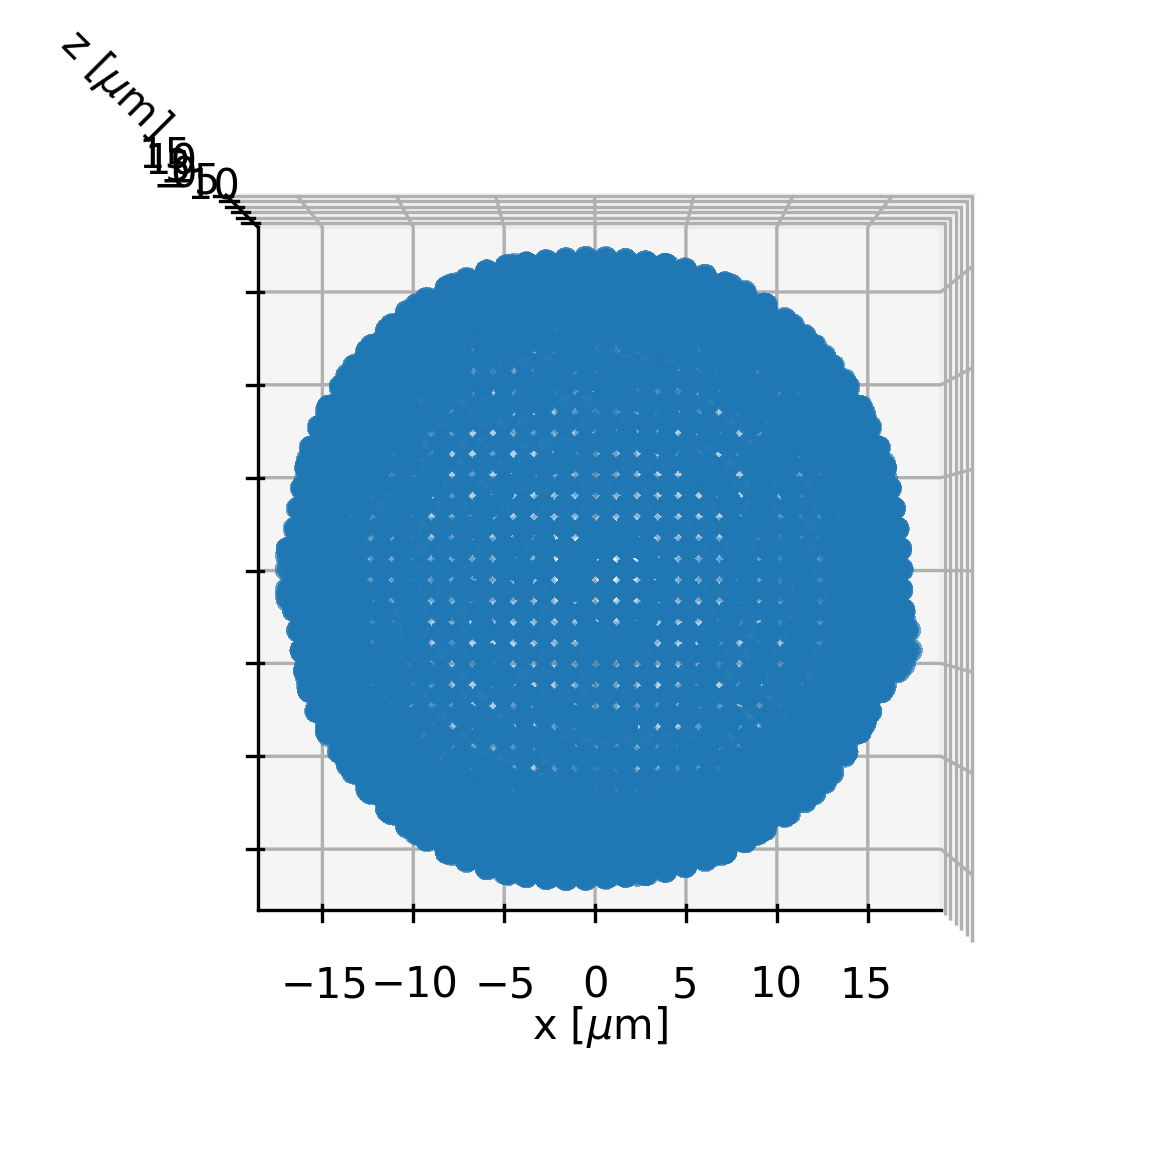

In [ ]:
fig,ax=plt.subplots(1,1,subplot_kw={"projection": "3d"})
#plot a vertical plane at x=-15
ax.scatter3D(vertexmod2[:,0],vertexmod2[:,1],vertexmod2[:,2],antialiased=False)
ax.view_init(90,270)
ax.set_zlabel(r'z [$\mu$m]')
ax.set_xlabel(r'x [$\mu$m]')
ax.yaxis.set_ticklabels([])
plt.gcf().set_dpi(300)
#set_axes_equal(ax)

In [20]:
############################# change inputs here #################################
# Data file name
shapename = 'noise'
E0=1100; nu0 = 0.4
# Material properties
mu0 = lame_mu(E0, nu0);
print(mu0)
r0 = 15.37;           # microns


# Spherical Harmonics Analysis Settings
lJmax = 20; lKmax = lJmax; lmax_plot = 60;
lmax_gen=200
noise_level=0

# initial guess settings
init_guess_type = 'ur-only' #'ur-only' or 'true'

# regularizations
myalpha = 1     # traction magnitude
mybeta  = 1  # coefficient magnitude
mygamma = 0.3   # anti-aliasing parameter     (beta  in the paper)

# program switches
plot_figure = True
savefig = False
myord = 1; # myord: p-norm order (1-mean value)

# minimization settings
maxiter_per_period = 20
CG_gtol = 1e-7          # This determines how good we want the analysis to be
eps = 1e-4              # for jacobian

minimizer = 'CG'
minimizer_config = {'maxiter': maxiter_per_period, 'disp': True, 'gtol': CG_gtol}

# dump files for minimization
savename = shapename + ('_b%.0f_n%.1e_lmax%d'%(mybeta, noise_level, lJmax))


392.8571428571429


In [21]:
#@title Functions
def prep_run():
    target_args = (f_interp, lJmax, mybeta, myord, X0surf, X0, isTfv, Cmat, Dmat,
               mu0, nu0, np.array([1]), np.array([1]), eps, '2-point', (TresJac, EelJac, penJac), mygamma)
    u_surf = u0_surf.flatten().copy()

    print(u0_surf.shape)
    u_surf_list = [u_surf, ]
    tic_start = time.time()
    return target_args,u_surf_list
def get_damping():
    lmax = lJmax
    ldamp_hi = lmax; ldamp_lo = lmax - 5;
    lv, _ = LM_list(lmax); lv_ones = np.ones_like(lv);
    lv_lim = np.minimum(np.maximum(lv, ldamp_lo), ldamp_hi)
    ldamp = (np.maximum(lv_lim-ldamp_lo, 0) / (ldamp_hi - ldamp_lo))**1
    Q = spm.csr_matrix(np.diag(np.tile(ldamp, 3)).astype(complex))
    return Q

def get_Jacobians(printtimes=False):
    Q=get_damping()
    # Calculating L, S, P matrices for Jacobian evaluation
    tic = time.time()
    Lmat = genLmat(lJmax, Cmat=Cmat, Dmat=Dmat)
    if printtimes:
        print('Time for generating L matrix: %.2fs'%(time.time() - tic))
    tic = time.time()
    Smat = genSmat(lJmax, Cmat=Cmat, Dmat=Dmat)
    if printtimes:
        print('Time for generating S matrix: %.2fs'%(time.time() - tic))
    Dinv = spm.linalg.inv(Dmat)
    CDmat = Cmat.dot(Dinv)
    tic = time.time()
    CDSmat = np.asmatrix(CDmat.dot(Smat))
    SHCDS = np.asmatrix(Smat).H.dot(CDSmat)
    if printtimes:
        print('Time for generating S^HCD^{-1}S matrix: %.2fs'%(time.time() - tic))
    tic = time.time()
    QCDSmat = Q.dot(CDSmat)
    QCDSHQCDS = QCDSmat.H.dot(QCDSmat).real
    if printtimes:
        print('Time for generating QCDSHQCDS matrix: %.2fs'%(time.time() - tic))
    tic = time.time()
    P = np.diag(np.stack([isTfv]*3, axis=-1).flatten())
    TresJac = myalpha*2*np.asmatrix(np.dot(np.dot(Lmat.T, P), Lmat))/(lJmax+1)/(lJmax*2+1)
    EelJac  = mybeta*2*np.pi*(SHCDS+SHCDS.H)
    penJac  = mygamma*(QCDSHQCDS+QCDSHQCDS.H)
    if printtimes:
        print('time of matrix build:', time.time() - tic)
    return TresJac, EelJac, penJac, Q

def get_interp(print_res=False):
    f_interp = Ur_interp(Vp/r0, lmax=lJmax+20, plot_figure=plot_figure)
    # Define shape reference points
    latsdeg, lonsdeg = pyshtools.expand.GLQGridCoord(lJmax, extend=True)
    lon0, lat0 = np.meshgrid(lonsdeg, latsdeg)
    X0surf = np.stack([lat0, lon0], axis=-1)
    X0 = GLQCartCoord(lJmax)
    u0_surf = np.zeros((lJmax+1, lJmax*2+2, 2))
    if print_res:
        U0vec, aK, T0vec = usurf2vec(u0_surf, f_interp=f_interp, lmax=lJmax)
    return f_interp, X0surf, X0, u0_surf

def print_residual_E_el():
    T0dist = Tvec2Tres(T0vec, lJmax, isTfv=isTfv, norm_order=myord)
    E0el = np.vdot(U0vec, T0vec).real*2*np.pi
    print('Traction residual: %.4e Pa'%(np.sqrt(T0dist)*mu0))
    print('Elastic energy: %.4e pJ'%(E0el*(r0/1e6)**3*mu0*1e12))
    print('funval: %.4e %.4e'%(T0dist, E0el))

def print_iter(xk):
    Uvec, aK, Tvec = usurf2vec(xk, f_interp, lJmax, X0surf=X0surf, X0=X0, Cmat=Cmat, Dmat=Dmat)
    Tdist = Tvec2Tres(Tvec, lJmax, isTfv=isTfv, norm_order=myord)
    Eel = np.vdot(Uvec, Tvec).real*2*np.pi
    pen = np.vdot(Q.dot(Tvec), Q.dot(Tvec)).real
    dr  = usurf2dr2(xk, *target_args)
    print('%13.4ePa%13.4epJ%13.4e%13.4e%13.4e%13.4e'%(np.sqrt(Tdist)*mu0, Eel*(r0/1e6)**3*mu0*1e12, Tdist, Eel, pen, dr))

def run_iters(N_iterations,usurfload=False):
    u_surf=u_surf_list[-1]
    tic_start = time.time()
    for i in range(N_iterations):
        print('Period %4d  Tr'%i, ' '*10, 'Eel', ' '*9, 'f0',' '*9, 'f1', ' '*9, 'f2', ' '*9, 'f')
        tic = time.time()
        u_res = minimize(usurf2dr2, u_surf.flatten(), args=target_args, jac=grad_usurf2dr2,
                        method = minimizer, options=minimizer_config, callback=print_iter)
        print('Iteration Time: %.2fs'%(time.time() - tic))
        u_surf = u_res.x.copy()
        u_surf_list.append(u_surf)
        if u_res.success:
            break
    print('Total Wall Time: %.2fs'%(time.time() - tic_start))
    return u_surf


In [22]:

#Umodes.mat
Cmat, Dmat = loadCoeffs(mu0, nu0, lJmax, 'reg',coeff_dir='/content/drive/MyDrive/Drive_Masterarbeit/Module/shelastic/default_modes')

Integrating modes to a matrix
1323 1323
Integrating modes to a matrix
1323 1323


shape fitting accuracy: 0.0004242204151774342


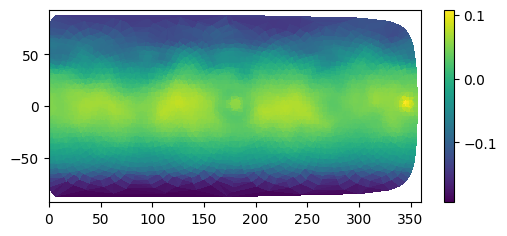

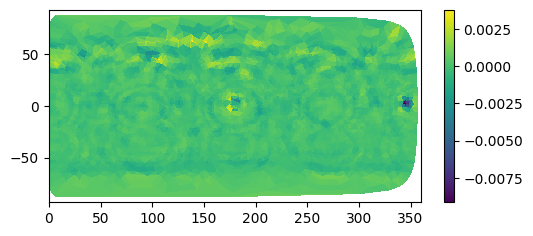

In [23]:
isTfv=np.zeros((21,42),dtype=bool)
isTfv[:5]=np.ones_like(isTfv[:5])
isTfv[-5:]=np.ones_like(isTfv[10:15])
#Vp=vertexmod2
TresJac, EelJac, penJac,Q = get_Jacobians()
f_interp, X0surf, X0, u0_surf=get_interp()


In [24]:
isTfv=np.zeros((21,42),dtype=bool)
target_args,u_surf_list= prep_run()
u_surf=run_iters(2)

(21, 42, 2)
Period    0  Tr            Eel           f0           f1           f2           f
   0.0000e+00Pa   1.4268e-01pJ   0.0000e+00   1.0002e-01   6.2323e-03   1.0189e-01
   0.0000e+00Pa   1.2771e-01pJ   0.0000e+00   8.9530e-02   6.1858e-03   9.1386e-02
   0.0000e+00Pa   1.2182e-01pJ   0.0000e+00   8.5397e-02   9.4294e-03   8.8226e-02
   0.0000e+00Pa   1.1929e-01pJ   0.0000e+00   8.3627e-02   3.4642e-03   8.4666e-02
   0.0000e+00Pa   1.1900e-01pJ   0.0000e+00   8.3425e-02   3.7811e-03   8.4560e-02
   0.0000e+00Pa   1.1853e-01pJ   0.0000e+00   8.3091e-02   2.1978e-03   8.3750e-02
   0.0000e+00Pa   1.1855e-01pJ   0.0000e+00   8.3108e-02   2.1025e-03   8.3739e-02


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:777: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_cg(fun, x0, args, jac, callback, **options)


         Current function value: 0.083739
         Iterations: 7
         Function evaluations: 114
         Gradient evaluations: 102
Iteration Time: 28.02s
Period    1  Tr            Eel           f0           f1           f2           f
         Current function value: 0.083739
         Iterations: 0
         Function evaluations: 55
         Gradient evaluations: 43
Iteration Time: 11.76s
Total Wall Time: 39.78s


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:777: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_cg(fun, x0, args, jac, callback, **options)


Traction residual: 0.0000e+00 Pa
Elastic energy: 1.1855e-01 pJ
funval: 0.0000e+00 8.3108e-02


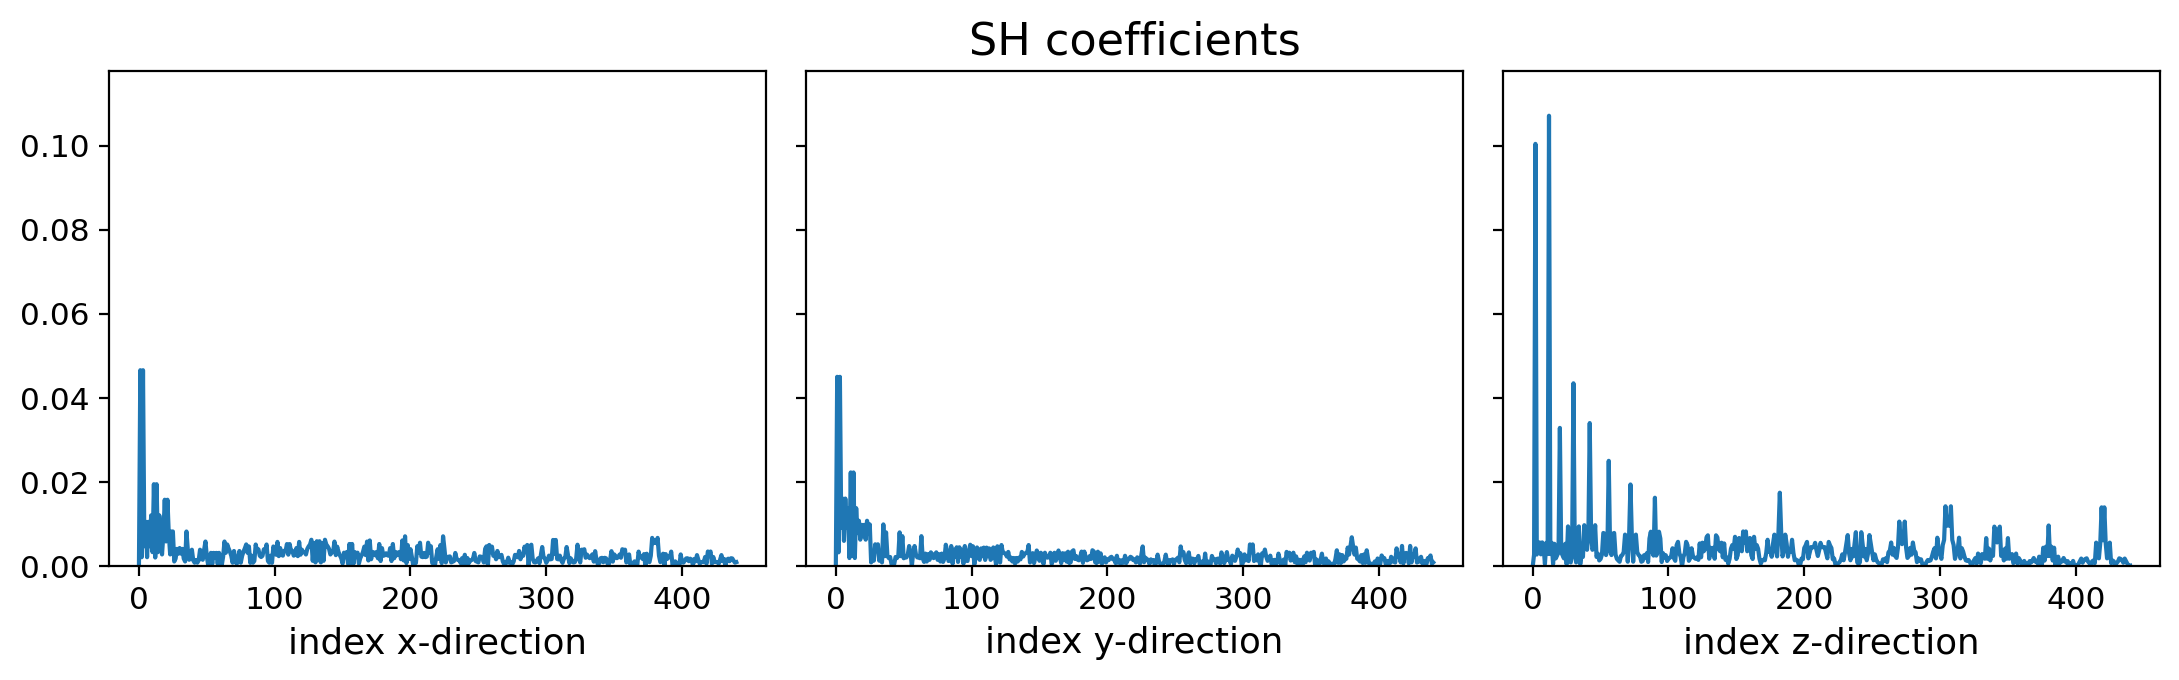

In [25]:


## Evaluation

Usurfvec, aK, Tsurfvec = usurf2vec(u_surf, f_interp, lJmax, X0surf=X0surf, X0=X0, Cmat=Cmat, Dmat=Dmat)
Tsurfdist = Tvec2Tres(Tsurfvec, lJmax, isTfv=isTfv, norm_order=myord)
Esurfel = np.vdot(Usurfvec, Tsurfvec).real*2*np.pi
print('Traction residual: %.4e Pa'%(np.sqrt(Tsurfdist)*mu0))
print('Elastic energy: %.4e pJ'%(Esurfel*(r0/1e6)**3*mu0*1e12))
print('funval: %.4e %.4e'%(Tsurfdist, Esurfel))

Textsize=16
plt.rcParams['axes.titlesize']=Textsize
plt.rcParams['axes.labelsize']=0.8*Textsize
nrange=None
srange=None
tveclength=len(Tsurfvec)
fig, ax = plt.subplots(1,3,figsize=(11,3.5))

labels=['$T_x$','$T_y$','$T_z$']
labels2=['x','y','z']
maxval=np.nanmax(np.abs(Tsurfvec))
for n in range(3):
    n0=n*int(tveclength/3)
    n1=(n+1)*int(tveclength/3)
    ax[n].tick_params(axis='both', which='major', labelsize=0.7*Textsize)
    ax[n].plot(np.abs(Tsurfvec[n0:n1]))#,  label='Reconstructed',alpha=0.7)

    ax[n].set_ylim(0,maxval*(1.1))
    #ax.legend()
    ax[n].set_xlabel('index '+labels2[n]+'-direction')
    if n!=0:
        ax[n].yaxis.set_ticklabels([])
ax[1].set_title('SH coefficients')

plt.gcf().set_dpi(200)

fig.tight_layout()

In [26]:
Tmesh=SHVec2mesh(Tsurfvec,SphCoord=False,Complex=True)
T_mesh2=Tmesh*mu0

/tmp/ipykernel_210/3970944654.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axx.set_xticklabels(["0", r"$\pi/2$", r"$\pi$"])
/tmp/ipykernel_210/3970944654.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axx.set_yticklabels(["0", r"$\pi$", r"$2\pi$"])
/tmp/ipykernel_210/3970944654.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axx.set_xticklabels(["0", r"$\pi/2$", r"$\pi$"])
/tmp/ipykernel_210/3970944654.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axx.set_yticklabels(["0", r"$\pi$", r"$2\pi$"])
/tmp/ipykernel_210/3970944654.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() o

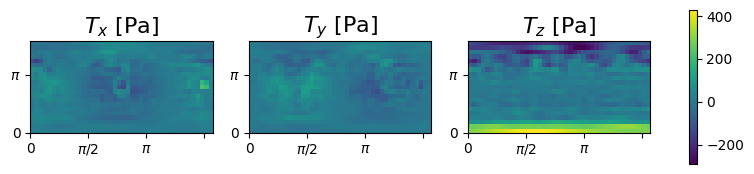

In [27]:
fig, ax= plt.subplots(1,3, figsize=(10,2))
x=ax[0].imshow(T_mesh2[:,:,0],vmin = np.min(T_mesh2), vmax= np.max(T_mesh2), extent = [0,2*np.pi,0,np.pi])
ax[1].imshow(T_mesh2[:,:,1],vmin = np.min(T_mesh2), vmax= np.max(T_mesh2), extent = [0,2*np.pi,0,np.pi])
ax[2].imshow(T_mesh2[:,:,2],vmin = np.min(T_mesh2), vmax= np.max(T_mesh2), extent = [0,2*np.pi,0,np.pi])
Titles = [r'$T_x$ [Pa]',r'$T_y$ [Pa]',r'$T_z$ [Pa]']
for n in range(3):
    ax[n].set_title(Titles[n])
for axx in ax:
    axx.set_xticklabels(["0", r"$\pi/2$", r"$\pi$"])
    axx.set_yticklabels(["0", r"$\pi$", r"$2\pi$"])

fig.colorbar(x,ax=ax)

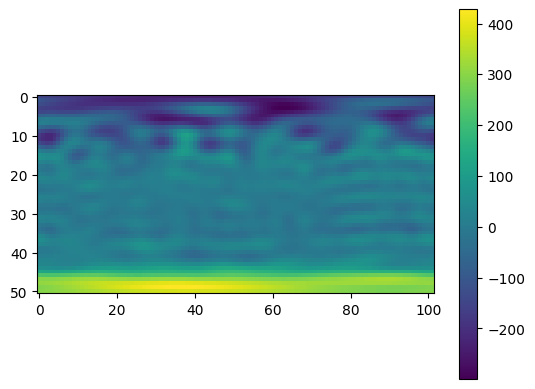

In [30]:
lplot = 50
radius=1
coord = GLQCartCoord(lplot)*radius
T_fine = SHVec2mesh(Tsurfvec, SphCoord=False, Complex=True, lmax = lplot)*mu0
u_fine = SHVec2mesh(Usurfvec, lmax = lplot, SphCoord=False, Complex=True)*radius
combined = coord+u_fine

folder = '/content/drive/MyDrive/Drive_Masterarbeit/Data_measurements/Oberflächenfunktionen/Results/'
#save to numpy
np.save(folder+'coord_ORD',coord)
np.save(folder+'T_fine_ORD',T_fine)
np.save(folder+'u_fine_ORD',u_fine)
np.save(folder+'combined_ORD',combined)
plt.imshow(T_fine[:,:,2])
plt.colorbar()

In [ ]:
plt.imshow()

In [ ]:
combined = np.reshape(coord+u_fine,(coord.shape[0]*coord.shape[1],3))*radius

print(Vp.shape)
print(combined.shape)

(4031, 3)
(5202, 3)


In [ ]:
plypath='/content/drive/MyDrive/Drive_Masterarbeit/Data_measurements/Oberflächenfunktionen/OGX_alter_adapter'
plydata = PlyData.read(plypath+'.ply')
vertex0=plydata['vertex']
vertex0=plydata['vertex']
numv=len(vertex0)
vertexonly=np.ones((numv,3))

for n in range(numv):
    for nn in range(3):
        vertexonly[n][nn]=vertex0[n][nn]
means=np.mean(vertexonly,0)
print(means)
vertexmod=np.zeros_like(vertexonly)
#prefactor2=35/29.4
prefactor2=1
for n in range(numv):
    for nn in range(3):
        if nn==2:
            prefactor=prefactor2
        else:
            prefactor=1
        vertexmod[n][nn]=prefactor*(vertexonly[n][nn]-means[nn])
Vp=vertexmod
from scipy.spatial import ConvexHull
hull = ConvexHull(Vp)
volume = hull.volume
radius = np.cbrt(0.75*volume/np.pi)
print("Convex hull volume:", volume)
print("Radius:", radius)

[24.22289643 23.56109851 13.81663855]


In [ ]:
Vp=vertexmod
#remove all vertices where x smaller -14
#vertexmod1=Vp[Vp[:,0]>-17]
#vertexmod2=vertexmod1[16.9>vertexmod1[:,0]]
#vertexmod2=Vp

In [ ]:
############################# change inputs here #################################
# Data file name
shapename = 'noise'
E0=1100; nu0 = 0.4
# Material properties
mu0 = lame_mu(E0, nu0);
print(mu0)
r0 = radius;           # microns


# Spherical Harmonics Analysis Settings
lJmax = 20; lKmax = lJmax; lmax_plot = 60;
lmax_gen=200
noise_level=0

# initial guess settings
init_guess_type = 'ur-only' #'ur-only' or 'true'

# regularizations
myalpha = 1     # traction magnitude
mybeta  = 1  # coefficient magnitude
mygamma = 0.3   # anti-aliasing parameter     (beta  in the paper)

# program switches
plot_figure = True
savefig = False
myord = 1; # myord: p-norm order (1-mean value)

# minimization settings
maxiter_per_period = 20
CG_gtol = 1e-7          # This determines how good we want the analysis to be
eps = 1e-4              # for jacobian

minimizer = 'CG'
minimizer_config = {'maxiter': maxiter_per_period, 'disp': True, 'gtol': CG_gtol}

# dump files for minimization
savename = shapename + ('_b%.0f_n%.1e_lmax%d'%(mybeta, noise_level, lJmax))


392.8571428571429


In [ ]:
#@title Functions
def prep_run():
    target_args = (f_interp, lJmax, mybeta, myord, X0surf, X0, isTfv, Cmat, Dmat,
               mu0, nu0, np.array([1]), np.array([1]), eps, '2-point', (TresJac, EelJac, penJac), mygamma)
    u_surf = u0_surf.flatten().copy()

    print(u0_surf.shape)
    u_surf_list = [u_surf, ]
    tic_start = time.time()
    return target_args,u_surf_list
def get_damping():
    lmax = lJmax
    ldamp_hi = lmax; ldamp_lo = lmax - 5;
    lv, _ = LM_list(lmax); lv_ones = np.ones_like(lv);
    lv_lim = np.minimum(np.maximum(lv, ldamp_lo), ldamp_hi)
    ldamp = (np.maximum(lv_lim-ldamp_lo, 0) / (ldamp_hi - ldamp_lo))**1
    Q = spm.csr_matrix(np.diag(np.tile(ldamp, 3)).astype(complex))
    return Q

def get_Jacobians(printtimes=False):
    Q=get_damping()
    # Calculating L, S, P matrices for Jacobian evaluation
    tic = time.time()
    Lmat = genLmat(lJmax, Cmat=Cmat, Dmat=Dmat)
    if printtimes:
        print('Time for generating L matrix: %.2fs'%(time.time() - tic))
    tic = time.time()
    Smat = genSmat(lJmax, Cmat=Cmat, Dmat=Dmat)
    if printtimes:
        print('Time for generating S matrix: %.2fs'%(time.time() - tic))
    Dinv = spm.linalg.inv(Dmat)
    CDmat = Cmat.dot(Dinv)
    tic = time.time()
    CDSmat = np.asmatrix(CDmat.dot(Smat))
    SHCDS = np.asmatrix(Smat).H.dot(CDSmat)
    if printtimes:
        print('Time for generating S^HCD^{-1}S matrix: %.2fs'%(time.time() - tic))
    tic = time.time()
    QCDSmat = Q.dot(CDSmat)
    QCDSHQCDS = QCDSmat.H.dot(QCDSmat).real
    if printtimes:
        print('Time for generating QCDSHQCDS matrix: %.2fs'%(time.time() - tic))
    tic = time.time()
    P = np.diag(np.stack([isTfv]*3, axis=-1).flatten())
    TresJac = myalpha*2*np.asmatrix(np.dot(np.dot(Lmat.T, P), Lmat))/(lJmax+1)/(lJmax*2+1)
    EelJac  = mybeta*2*np.pi*(SHCDS+SHCDS.H)
    penJac  = mygamma*(QCDSHQCDS+QCDSHQCDS.H)
    if printtimes:
        print('time of matrix build:', time.time() - tic)
    return TresJac, EelJac, penJac, Q

def get_interp(print_res=False):
    f_interp = Ur_interp(Vp/r0, lmax=lJmax+20, plot_figure=plot_figure)
    # Define shape reference points
    latsdeg, lonsdeg = pyshtools.expand.GLQGridCoord(lJmax, extend=True)
    lon0, lat0 = np.meshgrid(lonsdeg, latsdeg)
    X0surf = np.stack([lat0, lon0], axis=-1)
    X0 = GLQCartCoord(lJmax)
    u0_surf = np.zeros((lJmax+1, lJmax*2+2, 2))
    if print_res:
        U0vec, aK, T0vec = usurf2vec(u0_surf, f_interp=f_interp, lmax=lJmax)
    return f_interp, X0surf, X0, u0_surf

def print_residual_E_el():
    T0dist = Tvec2Tres(T0vec, lJmax, isTfv=isTfv, norm_order=myord)
    E0el = np.vdot(U0vec, T0vec).real*2*np.pi
    print('Traction residual: %.4e Pa'%(np.sqrt(T0dist)*mu0))
    print('Elastic energy: %.4e pJ'%(E0el*(r0/1e6)**3*mu0*1e12))
    print('funval: %.4e %.4e'%(T0dist, E0el))

def print_iter(xk):
    Uvec, aK, Tvec = usurf2vec(xk, f_interp, lJmax, X0surf=X0surf, X0=X0, Cmat=Cmat, Dmat=Dmat)
    Tdist = Tvec2Tres(Tvec, lJmax, isTfv=isTfv, norm_order=myord)
    Eel = np.vdot(Uvec, Tvec).real*2*np.pi
    pen = np.vdot(Q.dot(Tvec), Q.dot(Tvec)).real
    dr  = usurf2dr2(xk, *target_args)
    print('%13.4ePa%13.4epJ%13.4e%13.4e%13.4e%13.4e'%(np.sqrt(Tdist)*mu0, Eel*(r0/1e6)**3*mu0*1e12, Tdist, Eel, pen, dr))

def run_iters(N_iterations,usurfload=False):
    u_surf=u_surf_list[-1]
    tic_start = time.time()
    for i in range(N_iterations):
        print('Period %4d  Tr'%i, ' '*10, 'Eel', ' '*9, 'f0',' '*9, 'f1', ' '*9, 'f2', ' '*9, 'f')
        tic = time.time()
        u_res = minimize(usurf2dr2, u_surf.flatten(), args=target_args, jac=grad_usurf2dr2,
                        method = minimizer, options=minimizer_config, callback=print_iter)
        print('Iteration Time: %.2fs'%(time.time() - tic))
        u_surf = u_res.x.copy()
        u_surf_list.append(u_surf)
        if u_res.success:
            break
    print('Total Wall Time: %.2fs'%(time.time() - tic_start))
    return u_surf


In [ ]:

#Umodes.mat
Cmat, Dmat = loadCoeffs(mu0, nu0, lJmax, 'reg',coeff_dir='/content/drive/MyDrive/Drive_Masterarbeit/Module/shelastic/default_modes')

Integrating modes to a matrix
1323 1323
Integrating modes to a matrix
1323 1323


shape fitting accuracy: 0.0007175778771168915


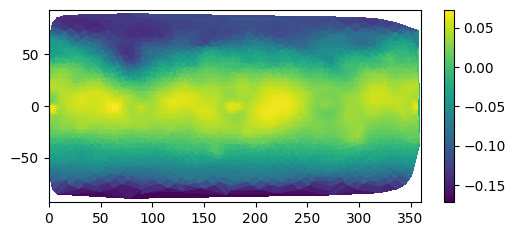

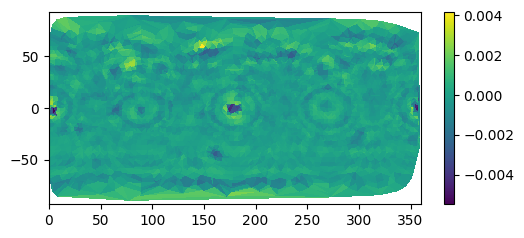

In [ ]:

isTfv=np.zeros((21,42),dtype=bool)
isTfv[:5]=np.ones_like(isTfv[:5])
isTfv[-5:]=np.ones_like(isTfv[10:15])
#Vp=vertexmod2
TresJac, EelJac, penJac,Q = get_Jacobians()
f_interp, X0surf, X0, u0_surf=get_interp()


In [ ]:
#target_args,u_surf_list= prep_run()
u_surf=run_iters(3)

Period    0  Tr            Eel           f0           f1           f2           f
   9.4191e+01Pa   1.0243e-01pJ   5.7484e-02   6.7244e-02   8.3626e-04   1.2498e-01
   9.4152e+01Pa   1.0230e-01pJ   5.7437e-02   6.7162e-02   8.2149e-04   1.2485e-01
   9.4136e+01Pa   1.0223e-01pJ   5.7417e-02   6.7113e-02   8.0394e-04   1.2477e-01
   9.4092e+01Pa   1.0216e-01pJ   5.7364e-02   6.7070e-02   7.9962e-04   1.2467e-01
   9.4074e+01Pa   1.0211e-01pJ   5.7341e-02   6.7037e-02   7.9819e-04   1.2462e-01
   9.4052e+01Pa   1.0208e-01pJ   5.7314e-02   6.7018e-02   7.9303e-04   1.2457e-01
   9.4043e+01Pa   1.0205e-01pJ   5.7304e-02   6.6996e-02   7.8526e-04   1.2454e-01
   9.4034e+01Pa   1.0201e-01pJ   5.7293e-02   6.6973e-02   7.8055e-04   1.2450e-01
   9.4022e+01Pa   1.0198e-01pJ   5.7278e-02   6.6953e-02   7.6852e-04   1.2446e-01
   9.4013e+01Pa   1.0192e-01pJ   5.7267e-02   6.6913e-02   7.6273e-04   1.2441e-01
   9.3993e+01Pa   1.0185e-01pJ   5.7243e-02   6.6865e-02   7.6466e-04   1.2434e-01
   9.

Traction residual: 9.3565e+01 Pa
Elastic energy: 1.0149e-01 pJ
funval: 5.6722e-02 6.6626e-02


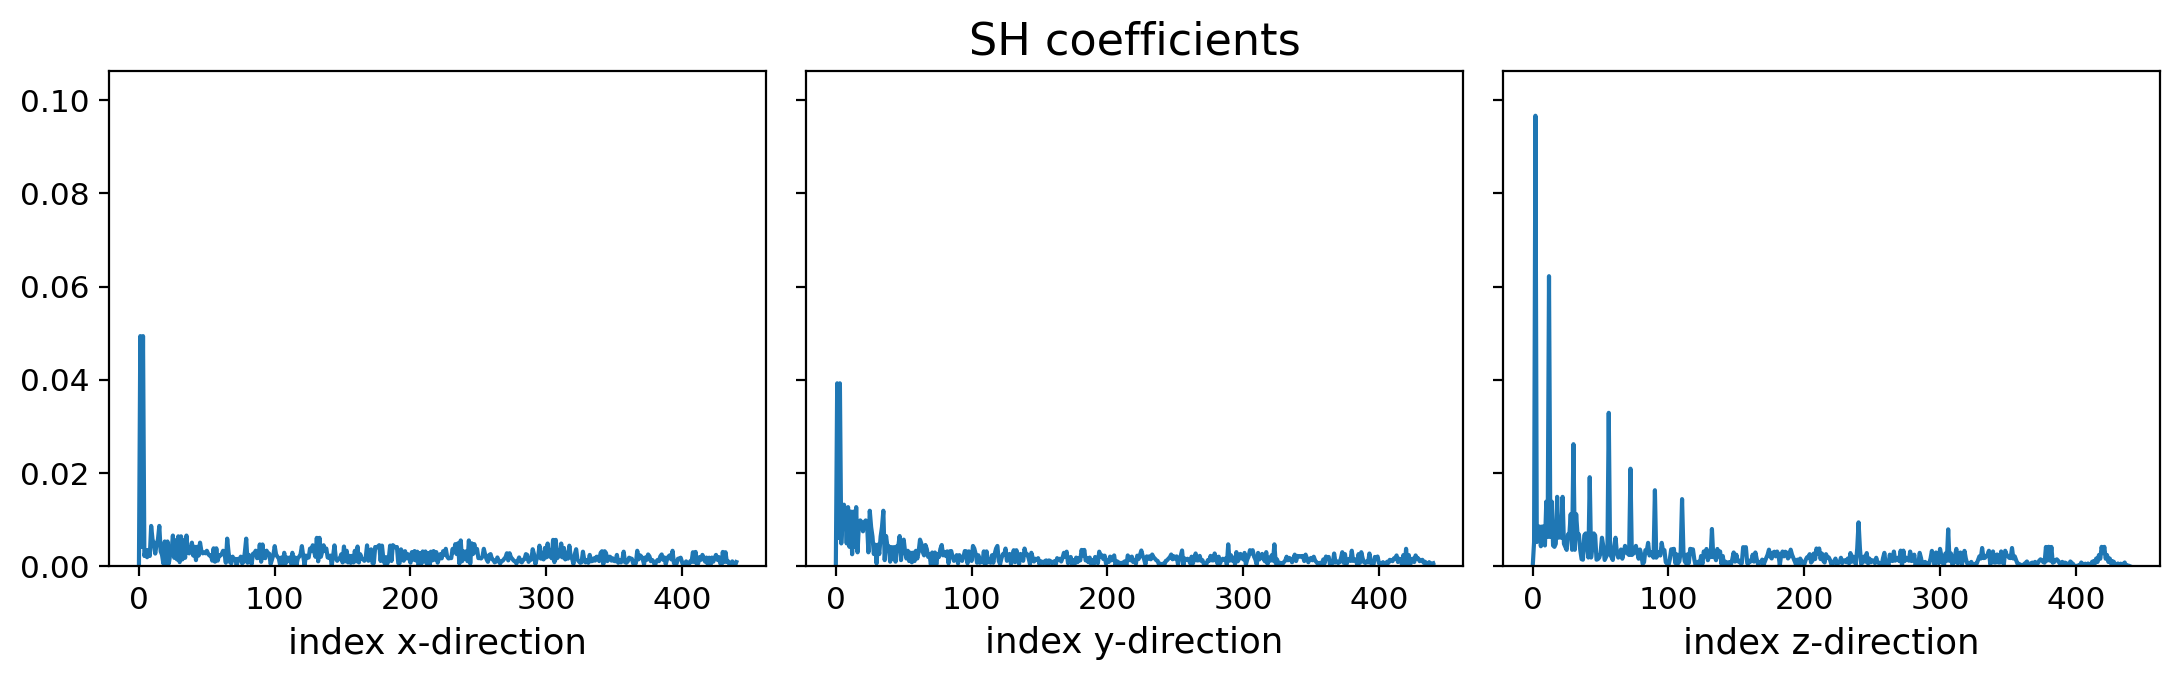

In [ ]:


## Evaluation

Usurfvec, aK, Tsurfvec = usurf2vec(u_surf, f_interp, lJmax, X0surf=X0surf, X0=X0, Cmat=Cmat, Dmat=Dmat)
Tsurfdist = Tvec2Tres(Tsurfvec, lJmax, isTfv=isTfv, norm_order=myord)
Esurfel = np.vdot(Usurfvec, Tsurfvec).real*2*np.pi
print('Traction residual: %.4e Pa'%(np.sqrt(Tsurfdist)*mu0))
print('Elastic energy: %.4e pJ'%(Esurfel*(r0/1e6)**3*mu0*1e12))
print('funval: %.4e %.4e'%(Tsurfdist, Esurfel))

Textsize=16
plt.rcParams['axes.titlesize']=Textsize
plt.rcParams['axes.labelsize']=0.8*Textsize
nrange=None
srange=None
tveclength=len(Tsurfvec)
fig, ax = plt.subplots(1,3,figsize=(11,3.5))

labels=['$T_x$','$T_y$','$T_z$']
labels2=['x','y','z']
maxval=np.nanmax(np.abs(Tsurfvec))
for n in range(3):
    n0=n*int(tveclength/3)
    n1=(n+1)*int(tveclength/3)
    ax[n].tick_params(axis='both', which='major', labelsize=0.7*Textsize)
    ax[n].plot(np.abs(Tsurfvec[n0:n1]))#,  label='Reconstructed',alpha=0.7)

    ax[n].set_ylim(0,maxval*(1.1))
    #ax.legend()
    ax[n].set_xlabel('index '+labels2[n]+'-direction')
    if n!=0:
        ax[n].yaxis.set_ticklabels([])
ax[1].set_title('SH coefficients')

plt.gcf().set_dpi(200)

fig.tight_layout()

In [ ]:
Tmesh=SHVec2mesh(Tsurfvec,SphCoord=False,Complex=True)
T_mesh2=Tmesh*mu0

/tmp/ipython-input-3970944654.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axx.set_xticklabels(["0", r"$\pi/2$", r"$\pi$"])
/tmp/ipython-input-3970944654.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axx.set_yticklabels(["0", r"$\pi$", r"$2\pi$"])
/tmp/ipython-input-3970944654.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axx.set_xticklabels(["0", r"$\pi/2$", r"$\pi$"])
/tmp/ipython-input-3970944654.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axx.set_yticklabels(["0", r"$\pi$", r"$2\pi$"])
/tmp/ipython-input-3970944654.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() o

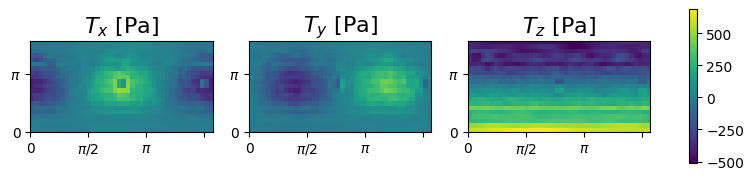

In [ ]:
fig, ax= plt.subplots(1,3, figsize=(10,2))
x=ax[0].imshow(T_mesh2[:,:,0],vmin = np.min(T_mesh2), vmax= np.max(T_mesh2), extent = [0,2*np.pi,0,np.pi])
ax[1].imshow(T_mesh2[:,:,1],vmin = np.min(T_mesh2), vmax= np.max(T_mesh2), extent = [0,2*np.pi,0,np.pi])
ax[2].imshow(T_mesh2[:,:,2],vmin = np.min(T_mesh2), vmax= np.max(T_mesh2), extent = [0,2*np.pi,0,np.pi])
Titles = [r'$T_x$ [Pa]',r'$T_y$ [Pa]',r'$T_z$ [Pa]']
for n in range(3):
    ax[n].set_title(Titles[n])
for axx in ax:
    axx.set_xticklabels(["0", r"$\pi/2$", r"$\pi$"])
    axx.set_yticklabels(["0", r"$\pi$", r"$2\pi$"])

fig.colorbar(x,ax=ax)

In [ ]:
lplot = 50
coord = GLQCartCoord(lplot)*radius
T_fine = SHVec2mesh(Tsurfvec, SphCoord=False, Complex=True, lmax = lplot)*mu0
u_fine = SHVec2mesh(Usurfvec, lmax = lplot, SphCoord=False, Complex=True)*radius
combined = coord+u_fine

folder = '/content/drive/MyDrive/Drive_Masterarbeit/Data_measurements/Oberflächenfunktionen/Results/'
#save to numpy
np.save(folder+'coord_OGX',coord)
np.save(folder+'T_fine_OGX',T_fine)
np.save(folder+'u_fine_OGX',u_fine)
np.save(folder+'combined_OGX',combined)

In [ ]:
T_fine.shape

(51, 102, 3)

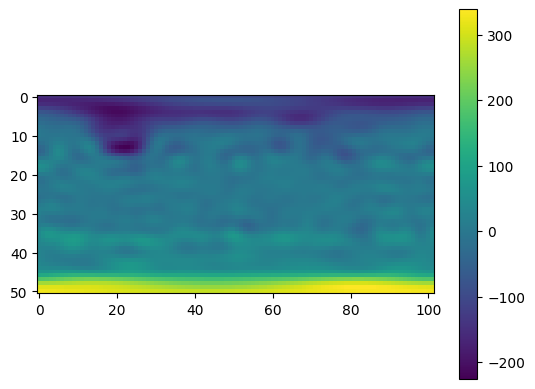

In [ ]:
plt.imshow(T_fine[:,:,2])
plt.colorbar()

# Comparison with simulation

In [ ]:
# @title Import of simulation classes
%%capture
class Axialsymmetric():
    def __init__(self,E1,v1,E2,v2,savefoldername,radius=1,nmax=20,
                savepath='/content/drive/MyDrive/Drive_Masterarbeit/Fenics(Dataexports)/',
                integralboundaries=False, sigma_zz_bool=False, symmetric=True,
                 norm_radius=1):
        #1 describes the sphere and 2 describes the wall/indenter/...
        #if you set symmetric to False, you need to define a sigma_zz_bottom
        #In this case, the program will automatically calculate the necessary
        #magnitude of sigma_zz_bottom in order for the Scenario to be possible
        #(i.e., the forces are balanced and sphere is not moving)

        self.E1=E1*norm_radius
        self.norm_radius=norm_radius
        self.v1=v1
        self.E2=E2
        self.v2=v2
        self.calc_E_star()
        self.E=self.E1
        self.pr=self.v1
        self.G=self.E/(2*(1+self.pr))
        self.mu=self.G
        self.savepath=savepath
        now=date.today()
        self.datestring=now.strftime("%d%b%y")
        self.savefoldername=savefoldername
        self.radius=radius
        self.update_fullpath()
        #the spacing is determined by the FIDVC algorithm, the default ist 4
        self.norm_radius=norm_radius

        self.plotextent=[0,1,0,self.radius]
        if not os.path.exists(self.fullsavepath):
            os.makedirs(self.fullsavepath)
        self.nmax=nmax
        self.coefficient_ns=range(0,self.nmax+1)
        self.coefficients_an=np.zeros((self.nmax+1))
        self.coefficients_bn=np.zeros((self.nmax+1))
        self.symmetric=symmetric
        self.prefactor_bottom=1
        if not self.symmetric:
            self.sigma_zz=self.sigma_zz_asymmetric
            self.calc_prefactor()
        if integralboundaries==False:
            self.integralboundaries=[0,np.pi]
        else:
            self.integralboundaries=integralboundaries
        self.sigma_zz_bool=sigma_zz_bool
        if sigma_zz_bool:
            self.sigma_rr_true=self.sigma_rr_true_zz
            self.sigma_rt_true=self.sigma_rt_true_zz

    def sigma_rr_true_zz(self,th):
        return self.sigma_zz(th)*np.cos(th)
    def sigma_rt_true_zz(self,th):
        val=-self.sigma_zz(th)*np.sin(th)
        return val

    def sigma_zz_asymmetric(self,th):
        if th<=np.pi/2:
            return self.sigma_zz_top(th)
        else:
            return self.prefactor_bottom*self.sigma_zz_bottom(th)


    def update_infostring(self,multi_E=False,multi_nu=False):
        if multi_E==False:
            ym=self.E
        else:
            ym=str(multi_E)
        if multi_nu==False:
            pr=self.pr
        else:
            pr=str(multi_nu)
        extrastring=''
        if hasattr(self, 'F'):
            extrastring+='F='+str(self.F)+'_'
        if hasattr(self, 'a'):
            extrastring+='a='+str(self.a)+'_'
        if self.radius!=1:
            extrastring+='Radius='+str(self.radius)+'_'
        self.infostring_all=(extrastring+'E='+str(ym)[:6]+'_nu='+str(pr)+'_')
    def update_fullpath(self,customfoldername=False,custompath=False):
        self.update_infostring()
        if customfoldername!=False:
            self.savefoldername=customfoldername
        if custompath!=False:
            self.savepath=custompath
        self.fullsavepath=self.savepath+self.savefoldername+self.datestring+self.infostring_all+'0/'

    def new_run(self,number):
        self.fullsavepath=self.fullsavepath[:-2]+str(number)+'/'
        os.makedirs(self.fullsavepath)


    def rts(self,x,p=2):
        #rounds to significant digits, #digits specified by p
        return float(np.format_float_scientific(x, precision=p, unique=False, trim='k'))

    def calc_E_star(self):
        self.E_star= 1/((1-self.v1**2)/self.E1 + (1-self.v2**2)/self.E2)

    def ortho_relation_L0(self,n):
        return 2/(2*n+1)

    def ortho_relation_L1(self,n):
        if n==0:
            n0=1
        else:
            n0=n
        return 2/(2*n+1)*(n+1)*n0

    def get_ortho_relations_pref(self):
        self.L0=np.zeros(self.nmax+1)
        self.L1=np.zeros(self.nmax+1)
        for n in range(self.nmax+1):
            self.L0[n]=self.ortho_relation_L0(n)
            self.L1[n]=self.ortho_relation_L1(n)
    def calc_prefactor(self,return_=False):
        a1_rr_top=self.calc_integral_rr(n=1,toponly=True)
        a1_rr_bottom=self.calc_integral_rr(n=1,bottomonly=True)
        a1_rt_top=self.calc_integral_rt(n=1,toponly=True)
        a1_rt_bottom=self.calc_integral_rt(n=1,bottomonly=True)
        A=-(a1_rr_top+a1_rt_top)/(a1_rr_bottom+a1_rt_bottom)
        if self.prefactor_bottom==1:
            self.prefactor_bottom=A
        else:
            print("Warning! Prefactor was already calculated" )
        if return_:
            return A

    def plotdata_u(self,rsteps=100,thsteps=100,thetarange=False,rrange=False,
                   savedata=True,saveplot=True,plot_=True,scale=5):
        #creates plotdata for u_r, u_th, and the magnitude of both combined.
        self.u_r_plot=np.zeros((rsteps,thsteps))
        self.u_th_plot=np.zeros((rsteps,thsteps))
        self.u_mag_plot=np.zeros((rsteps,thsteps))
        self.X_th=np.linspace(0,np.pi,thsteps)
        self.X_r=np.flip(np.linspace(0,self.radius,rsteps))
        if thetarange!= False:
            self.X_th=np.linspace(thetarange[0],thetarange[1],thsteps)
            self.plotextent[0]=self.rts(thetarange[0]/np.pi)
            self.plotextent[1]=self.rts(thetarange[1]/np.pi)
        if rrange!=False:
            self.X_r=np.flip(np.linspace(rrange[0],rrange[1],rsteps))
            self.plotextent[2]=rrange[0]
            self.plotextent[3]=rrange[1]
        for n,xr in enumerate(self.X_r):
            for nn,xth in enumerate(self.X_th):
                a=self.u_r(xth,xr)
                self.u_r_plot[n][nn]=a
                b=self.u_th(xth,xr)
                self.u_th_plot[n][nn]=b
                self.u_mag_plot[n][nn]=np.sqrt(a**2+b**2)
        self.update_infostring()
        self.all_u_data=[self.u_r_plot,self.u_th_plot,self.u_mag_plot]
        if savedata:
            np.save(self.fullsavepath+'u_plotdata'+self.infostring_all+'npy',self.all_u_data)
        if plot_:
            self.plot_u(saveplot,scale=scale)

    def plot_u(self,saveplot=True,show=True,scale=2,samescale=True):
        #plots the data created with plotdata
        nx=3
        ny=1
        sizex=scale*(2*nx+2)
        sizey=scale*(1*ny+1)
        min_val, max_val = np.nanmin(self.all_u_data), np.nanmax(self.all_u_data)

        fig=plt.figure(figsize=(sizex,sizey))
        fig.suptitle('Displacement u')
        for n, u in enumerate([self.u_r_plot,self.u_th_plot,self.u_mag_plot]):
            ax=fig.add_subplot(1,3,n+1)
            if samescale:
                ax.imshow(u,extent=self.plotextent,
                      vmin=min_val,vmax=max_val)
            else:
                ax.imshow(u,extent=self.plotextent)
                ax.colorbar()
            ax.xaxis.set_major_formatter(tck.FormatStrFormatter('%g $\pi$'))
            ax.xaxis.set_major_locator(tck.MultipleLocator(base=0.25))
            if n==0:
                ax.set_xlabel('angle θ')
                ax.set_ylabel('radius r, \n ')
                ax.set_title('radial direction')
            if n==1:
                ax.set_title('theta direction')
            if n==2:
                ax.set_title('total magnitude')
        if samescale:
            fig.tight_layout()
            fig.canvas.draw()
            fig.subplots_adjust(right=0.8)
            cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
            norm = mpl.colors.Normalize(vmin=min_val, vmax=max_val)
            scm=mpl.cm.ScalarMappable(norm=norm)
            fig.colorbar(scm,cax=cbar_ax)

        if saveplot:
            filename=self.fullsavepath+'u_plot'+self.infostring_all+".svg"
            fig.savefig(filename,format='svg')
        if show:
            fig.show

    def data_sigma_sim(self,rsteps=100,thsteps=100,thetarange=False,rrange=False,savedata=True,
                       forcomp=False):
        self.sigma_rr_sim_plot=np.zeros((rsteps,thsteps))
        self.sigma_rt_sim_plot=np.zeros((rsteps,thsteps))
        self.X_th=np.linspace(0,np.pi,thsteps)
        self.X_r=np.flip(np.linspace(0,self.radius,rsteps))
        if thetarange!= False:
            self.X_th=np.linspace(thetarange[0],thetarange[1],thsteps)
            self.plotextent[0]=self.rts(thetarange[0]/np.pi)
            self.plotextent[1]=self.rts(thetarange[1]/np.pi)
        if rrange!=False:
            self.X_r=np.flip(np.linspace(rrange[0],rrange[1],rsteps))
            self.plotextent[2]=rrange[0]
            self.plotextent[3]=rrange[1]
        if forcomp:
            self.X_r=[self.radius]
        for n,xr in enumerate(self.X_r):
            for nn,xth in enumerate(self.X_th):
                a=self.sigma_rr(xth,xr)
                self.sigma_rr_sim_plot[n][nn]=a
                b=self.sigma_rt(xth,xr)
                self.sigma_rt_sim_plot[n][nn]=b
        self.update_infostring()
        self.all_sigma_sim_data=[self.sigma_rr_sim_plot,self.sigma_rt_sim_plot]
        if savedata:
            np.save(self.fullsavepath+'sigma_sim_plotdata'+self.infostring_all,self.all_sigma_sim_data)

    def data_sigma_true(self,thsteps=100,thetarange=False,rrange=False,savedata=True,saveplot=True,plot_=True,
                   scale=5):
        rsteps=1
        self.sigma_rr_true_plot=np.zeros((rsteps,thsteps))
        self.sigma_rt_true_plot=np.zeros((rsteps,thsteps))
        X_th=np.linspace(0,np.pi,thsteps)
        X_r=[self.radius]
        if thetarange!= False:
            X_th=np.linspace(thetarange[0],thetarange[1],thsteps)
        for nn,xth in enumerate(X_th):
            a=self.sigma_rr_true(xth)
            self.sigma_rr_true_plot[0][nn]=a
            b=self.sigma_rt_true(xth)
            self.sigma_rt_true_plot[0][nn]=b
        self.update_infostring()
        self.all_sigma_true_data=[self.sigma_rr_true_plot,self.sigma_rt_true_plot]
        if savedata:
            np.save(self.fullsavepath+'sigma_true_plotdata'+self.infostring_all,self.all_sigma_true_data)

    def plot_sigma(self,saveplot=True,show=True,scale=2,samescale=True):
        nx=2
        ny=1
        sizex=scale*(2*nx+2)
        sizey=scale*(1*ny+1)
        min_val, max_val = np.nanmin(self.all_u_data), np.nanmax(self.all_u_data)
        fig=plt.figure(figsize=(sizex,sizey))
        fig.suptitle('Sigma')
        for n, u in enumerate(self.all_sigma_sim_data):
            ax=fig.add_subplot(1,3,n+1)
            if samescale:
                ax.imshow(u,extent=self.plotextent,
                        vmin=min_val,vmax=max_val)
            else:
                ax.imshow(u,extent=self.plotextent)
                ax.colorbar()
            ax.xaxis.set_major_formatter(tck.FormatStrFormatter('%g $\pi$'))
            ax.xaxis.set_major_locator(tck.MultipleLocator(base=0.25))
            if n==0:
                ax.set_xlabel('angle θ')
                ax.set_ylabel('radius r, \n ')
                ax.set_title('radial direction')
            if n==1:
                ax.set_title('theta direction')

        if samescale:
            fig.tight_layout()
            fig.canvas.draw()
            fig.subplots_adjust(right=0.8)
            cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
            norm = mpl.colors.Normalize(vmin=min_val, vmax=max_val)
            scm=mpl.cm.ScalarMappable(norm=norm)
            fig.colorbar(scm,cax=cbar_ax)

        if saveplot:
            filename=('uplot_'+infostring_specific+
                        self.infostring_all+".svg")
            fig.savefig(filename,format='svg')
        if show:
            fig.show

    def compare_sigma(self,show_plot=True,radial=True,theta=False):
        self.data_sigma_sim(forcomp=True)
        self.data_sigma_true()

        if radial:
            plt.plot(self.X_th,self.sigma_rr_sim_plot[0],label='simulated')
            plt.plot(self.X_th,self.sigma_rr_true_plot[0],label='refernce')
            sigma_name='$\sigma_{rr}$ [Pa]'
        if theta:
            plt.plot(self.X_th,self.sigma_rt_sim_plot[0],label='simulated')
            plt.plot(self.X_th,self.sigma_rt_true_plot[0],label='refernce')
            sigma_name='$\sigma_{r\theta}$ [Pa]'
        plt.title('Comparing simulated and reference sigma values')
        plt.xlabel(r'$\theta$ [rad]')
        plt.ylabel(sigma_name)
        plt.legend()
        if show_plot:
            plt.show()


    def integrand_rr(self,th,n,toponly=False,bottomonly=False):
        if not (toponly or bottomonly):
            return self.sigma_rr_true(th)*np.sin(th)*scipy.special.lpmv(0,n,np.cos(th))
        elif toponly and th<=np.pi/2:
            return self.sigma_rr_true(th)*np.sin(th)*scipy.special.lpmv(0,n,np.cos(th))
        elif bottomonly and th>np.pi/2:
            return self.sigma_rr_true(th)*np.sin(th)*scipy.special.lpmv(0,n,np.cos(th))*self.prefactor_bottom
        else:
            return 0

    def integrand_rt(self,th,n,toponly=False,bottomonly=False):
        if not (toponly or bottomonly):
            return self.sigma_rt_true(th)*np.sin(th)*scipy.special.lpmv(1,n,np.cos(th))*self.prefactor_bottom
        elif toponly and th<=np.pi/2:
            return self.sigma_rt_true(th)*np.sin(th)*scipy.special.lpmv(1,n,np.cos(th))
        elif bottomonly and th>np.pi/2:
            return self.sigma_rt_true(th)*np.sin(th)*scipy.special.lpmv(1,n,np.cos(th))*self.prefactor_bottom
        else:
            return 0

    def calc_integral_rr(self,n,toponly=False,bottomonly=False,print_integral_value=False):
        bnumber=len(self.integralboundaries)
        I=0
        for nn in range(bnumber-1):
            lower=self.integralboundaries[nn]
            upper=self.integralboundaries[nn+1]
            I_=sp.integrate.quad(self.integrand_rr,lower,upper,args=(n,toponly,bottomonly))[0]
            if print_integral_value:
                print(I_)
            I+=I_
        prefactor=1/(2*self.G)/(self.ortho_relation_L0(n))
        if toponly or bottomonly:
            return I
        else:
            return I*prefactor

    def calc_integral_rt(self,n,toponly=False,bottomonly=False,print_integral_value=False):
        bnumber=len(self.integralboundaries)
        I=0
        for nn in range(bnumber-1):
            lower=self.integralboundaries[nn]
            upper=self.integralboundaries[nn+1]
            I_=sp.integrate.quad(self.integrand_rt,lower,upper,args=(n,toponly,bottomonly))[0]
            if print_integral_value:
                print(I_)
            I+=I_
        prefactor=1/(2*self.G)/(self.ortho_relation_L1(n))
        if toponly or bottomonly:
            return I
        else:
            return I*prefactor

    def integrand_AAD(self,th):
        #if self.sigma_zz_bool:
        #    val=np.sin(th)*np.abs(self.sigma_zz_true(th))
        val=np.sin(th)*np.sqrt(self.sigma_rt_true(th)**2+self.sigma_rr_true(th)**2)
        return val


    def calc_integral_AAD2_prefactor(self):
        I=sp.integrate.quad(self.integrand_AAD,0,np.pi,)[0]
        self.AAD2=I/np.pi


    def calc_coeff_matrix(self,n):
        c_a_rr=(n+1)*(n**2-n-2-2*self.pr)*self.radius**n
        c_b_rr=n*(n-1)*self.radius**(n-2)
        c_a_rt=(n**2+2*n-1+2*self.pr)*self.radius**n
        c_b_rt=(n-1)*self.radius**(n-2)
        return np.array([[c_a_rr,c_b_rr],[c_a_rt,c_b_rt]])


    def calc_and_store_lgs(self,printsteps=False):
        for n in range(0,self.nmax+1):
            if self.symmetric:
                if n % 2==0:
                    iterator=True
                else:
                    iterator=False
            else:
                iterator=True

            if iterator:
                I0=self.calc_integral_rr(n,print_integral_value=printsteps)
                I1=self.calc_integral_rt(n,print_integral_value=printsteps)
                I=np.array([I0,I1])
                A=self.calc_coeff_matrix(n)
                if printsteps:
                    print(n)
                    print(I)
                    print(A)
                if np.linalg.det(A)==0:
                    a=I0/A[0][0]
                    a2=I1/A[1][0]
                    b=0
                else:
                    a,b=np.linalg.solve(A,I)
                if printsteps:
                    print(a)
                    print(b)
                    print()
                self.coefficients_an[n]=a
                if n>1:
                    self.coefficients_bn[n]=b

                else:
                    self.coefficients_bn[n]=0



    def calc_other_coefficients(self):
        self.coefficients_an_u_r=np.zeros((self.nmax+1))
        self.coefficients_bn_u_r=np.zeros((self.nmax+1))

        self.coefficients_an_u_th=np.zeros((self.nmax+1))
        self.coefficients_bn_u_th=np.zeros((self.nmax+1))

        self.coefficients_an_sigma_rr=np.zeros((self.nmax+1))
        self.coefficients_bn_sigma_rr=np.zeros((self.nmax+1))

        self.coefficients_an_sigma_rth=np.zeros((self.nmax+1))
        self.coefficients_bn_sigma_rth=np.zeros((self.nmax+1))

        for n in self.coefficient_ns:
            an=self.coefficients_an[n]
            bn=self.coefficients_bn[n]

            self.coefficients_an_u_r[n]=an*(n+1)*(n-2+4*self.v1)
            self.coefficients_bn_u_r[n]=bn*n

            self.coefficients_an_u_th[n]=an*(n+5-4*self.v1)
            self.coefficients_bn_u_th[n]=bn

            self.coefficients_an_sigma_rr[n]=an*(n+1)*(n**2-n-2-2*self.v1)
            self.coefficients_bn_sigma_rr[n]=bn*n*(n-1)

            self.coefficients_an_sigma_rth[n]=an*(n**2+2*n-1+2*self.v1)
            self.coefficients_bn_sigma_rth[n]=bn*(n-1)


    def u_r(self,theta,r=None):
        value=0
        if np.all(r)==None or r == None:
            r=self.radius
        if r==None or self.radius==None:
            print(r)
            print(self.radius)
        if r==0 or r>self.radius*1.1:
            return 0
        else:
            for n in self.coefficient_ns:
                value+=(self.coefficients_an_u_r[n]*r**(n+1)+self.coefficients_bn_u_r[n]*r**(n-1))*sp.special.lpmv(0,n,np.cos(theta))
            return value

    def u_th(self,theta,r=None):
        value=0
        if np.all(r)==None or r == None:
            r=self.radius
        if r==0 or r>self.radius*1.1:
            return 0
        else:
            for n in self.coefficient_ns:
                value+=(self.coefficients_an_u_th[n]*r**(n+1)+self.coefficients_bn_u_th[n]*r**(n-1))*sp.special.lpmv(1,n,np.cos(theta))
            return value

    def sigma_rr(self,theta,r=None):
        value=0
        if r==None:
            r=self.radius
        if r==0:
            return 0
        else:
            for n in self.coefficient_ns:
                value+=(self.coefficients_an_sigma_rr[n]*r**n+self.coefficients_bn_sigma_rr[n]*r**(n-2))*sp.special.lpmv(0,n,np.cos(theta))
            return 2*self.G*value

    def sigma_rt(self,theta,r=None):
        value=0
        if r==None:
            r=self.radius
        for n in self.coefficient_ns:
            if n!=0:
                value+=(self.coefficients_an_sigma_rth[n]*r**n+self.coefficients_bn_sigma_rth[n]*r**(n-2))*sp.special.lpmv(1,n,np.cos(theta))
        return 2*self.G*value

    def GLQCartCoord(self,lmax,extend=False):
        '''Compute the Cartesian coordinates used in Gauss-Legendre quadrature grids on
            a unit sphere.
            Usage
            -----
            X0 = GLQCartCoord (lmax)
            Returns
            -------
            X0 : float, dimension (lmax+1, 2*lmax+1, 3)
                The Cartesian coordinates of a GLQ grid on a unit sphere
            Parameters
            ----------
            lmax : integer
                The maximum spherical harmonic degree that will be integrated exactly by
                Gauss-Legendre quadrature.
        '''
        latsdeg, lonsdeg = _psh.expand.GLQGridCoord(lmax,extend=extend)
        lon = np.deg2rad(lonsdeg)
        colat = np.deg2rad(90-latsdeg)
        PHI, THETA = np.meshgrid(lon, colat)
        R = np.ones_like(PHI)
        X,Y,Z = self.SphCoord_to_CartCoord(R, THETA, PHI)
        return np.stack([X,Y,Z], axis=-1)

    def SphCoord_to_CartCoord(self, R, THETA, PHI):
        """translate spherical coordinates into Cartesian coordinates
            Parameters
            ----------
            R,THETA,PHI : ndarray
                make sure R, THETA, PHI have the same dimensions

            Returns
            -------
            X,Y,Z : ndarray
                same size as R, THETA, PHI.

        """
        Z = R * np.cos(THETA)
        X = R * np.sin(THETA) * np.cos(PHI)
        Y = R * np.sin(THETA) * np.sin(PHI)
        return (X, Y, Z)

    def distance(self,a,b):
            l=len(a)
            return np.sqrt(sum([(a[n]-b[n])**2 for n in range (l)]))

    def cart_to_sph_coords(self,vector):
        #input [x,y,z]
        #output [r,theta,phi]
        x,y,z=vector
        r=np.linalg.norm(vector)
        '''
        if y==0:
            if x>=0:
                phi=0
            else:
                phi=np.pi
        elif x==0:
            if y>=0:
                phi=np.pi/2
            else:
                phi=3*np.pi/2
        else:
        '''
        phi=np.arctan2(y,x)
        if z==0:
            theta=np.pi/2
        else:
            theta=np.arccos(z/r)
        return np.array([r,theta,phi])

    def vector_sph_to_cart(self,vector,theta,phi):
        A=np.array([[np.sin(theta)*np.cos(phi),np.cos(theta)*np.cos(phi),-np.sin(phi)],
            [np.sin(theta)*np.sin(phi),np.cos(theta)*np.sin(phi),np.cos(phi)],
            [np.cos(theta),-np.sin(theta),0]])
        return A.dot(vector)
    def vector_cart_to_sph(self,vector,theta,phi):
        A=np.array([[np.sin(theta)*np.cos(phi),np.cos(theta)*np.cos(phi),-np.sin(phi)],
            [np.sin(theta)*np.sin(phi),np.cos(theta)*np.sin(phi),np.cos(phi)],
            [np.cos(theta),-np.sin(theta),0]]).transpose()
        return A.dot(vector)

    def tensor_cart_to_sph(self,vector,theta,phi):
        A=np.array([[np.sin(theta)*np.cos(phi),np.cos(theta)*np.cos(phi),-np.sin(phi)],
            [np.sin(theta)*np.sin(phi),np.cos(theta)*np.sin(phi),np.cos(phi)],
            [np.cos(theta),-np.sin(theta),0]])
        return A.dot(A.transpose().dot(vector))
    def tensor_sph_to_cart(self,vector,theta,phi):
        A=np.array([[np.sin(theta)*np.cos(phi),np.cos(theta)*np.cos(phi),-np.sin(phi)],
            [np.sin(theta)*np.sin(phi),np.cos(theta)*np.sin(phi),np.cos(phi)],
            [np.cos(theta),-np.sin(theta),0]])
        return A.transpose().dot(A.dot(vector))

    def u_quarterplot(self,dpi=300):
        plt.rcParams['figure.figsize']=[5,5]
        numpoints=400
        xrange=np.linspace(-1,0,numpoints)
        zrange=np.sqrt(1-xrange**2)
        plt.plot(xrange,zrange,label='undeformed')
        _,th,p=CartCoord_to_SphCoord(xrange,np.zeros_like(xrange),zrange)
        xrange2=xrange.copy()
        zrange2=zrange.copy()
        dispx=np.zeros_like(xrange)
        dispz=np.zeros_like(zrange)
        for n in range(numpoints):
            thn=th[n]
            ur=self.u_r(thn)
            #print(ur)
            ut=self.u_th(thn)
            u=[ur,ut,0]
            ux,uy,uz=self.vector_sph_to_cart(u,thn,-np.pi)
            xrange2[n]+=ux
            zrange2[n]+=uz
            dispx[n]=ux
            dispz[n]=uz
        plt.plot(xrange2,zrange2,label='deformed')
        thetas=np.linspace(np.pi/2,0,11)
        x_arrows=int((1-np.sin(thetas))*numpoints)-1
        #for n in range(0,numpoints,40):
        for n in x_arrows[1:]:
            arrow=plt.arrow(xrange[n],zrange[n],dispx[n],dispz[n],length_includes_head=True,head_width=0.02, head_length=0.02)
                    #label=r'$\vec{u}$')
        plt.axis('off')
        plt.legend()
        filename=self.fullsavepath+'u_plot'+self.infostring_all+".svg"
        plt.savefig(filename,format='svg',dpi=dpi)
        plt.show()


    def u_halfplot(self,dpi=300,add2a=False,forringrange=0,rangefactor=0,
                   ztop=1.2,add_arrow=True,savesvgname=''):
        factor=1+rangefactor
        plt.rcParams['figure.figsize']=[10,5*factor]
        numpoints=400
        xrange=np.linspace(-1,0,numpoints)
        zrange=np.sqrt(1-xrange**2)
        xrange0=np.linspace(-1,1,numpoints*2-1)
        zrange0=extendflip(zrange)
        plt.plot(xrange0,zrange0,label='undeformed')
        _,th,p=CartCoord_to_SphCoord(xrange,np.zeros_like(xrange),zrange)
        xrange2=xrange.copy()
        zrange2=zrange.copy()
        dispx=np.zeros_like(xrange)
        dispz=np.zeros_like(zrange)
        for n in range(numpoints):
            thn=th[n]
            ur=self.u_r(thn)
            #print(ur)
            ut=self.u_th(thn)
            u=[ur,ut,0]
            ux,uy,uz=self.vector_sph_to_cart(u,thn,-np.pi)
            xrange2[n]+=ux
            zrange2[n]+=uz
            dispx[n]=ux
            dispz[n]=uz
        xrange3=np.append(xrange2,np.abs(np.flip(xrange2[:-1])))
        zrange3=extendflip(zrange2)
        dispx2=extendflip(dispx)
        dispz2=extendflip(dispz)
        plt.plot(xrange3,zrange3,label='deformed')
        thetas=np.linspace(np.pi/2,0,11)
        x_arrows=(((1-np.sin(thetas))*numpoints)-1).astype(int)
        x_arrows2=np.append(x_arrows,np.flip(2*numpoints-(x_arrows[1:]))-1)
        #for n in range(0,numpoints,40):
        print(x_arrows2)

        for n in x_arrows2[1:]:
            if n==numpoints:
                pass
                arrow1=arrow
            elif xrange0[n]>0:
                arrow=plt.arrow(xrange0[n],zrange0[n],-dispx2[n],dispz2[n],
                                length_includes_head=True,head_width=0.02,
                                head_length=0.02)
            else:
                arrow=plt.arrow(xrange0[n],zrange0[n],dispx2[n],dispz2[n],
                                length_includes_head=True,head_width=0.02,
                                head_length=0.02)
        if add2a:
            X1=np.linspace(-self.a,self.a,50)
            plt.plot(X1,(ztop+0.03)*self.radius*np.ones_like(X1),color='black')
            plt.text(-0.03, ztop+0.06, '2a',fontsize=17)
        plt.axis('off')

        filename=self.fullsavepath+'u_plot'+self.infostring_all+".svg"
        #plt.savefig(filename,format='png',dpi=dpi)
        plt.gcf().set_dpi(dpi)
        lowerbound=0
        if forringrange>0:
            plt.plot(xrange0[:forringrange],-zrange0[:forringrange],color='#1f77b4')
            plt.plot(xrange0[-forringrange:],-zrange0[-forringrange:],color='#1f77b4')
            plt.plot(xrange3[:forringrange],-zrange3[:forringrange],color='#ff7f0e')
            plt.plot(xrange3[-forringrange:],-zrange3[-forringrange:],color='#ff7f0e')
            arrow=plt.arrow(xrange0[0],zrange0[0],dispx2[0],dispz2[0],
                length_includes_head=True,head_width=0.02,
                head_length=0.02)
            arrow=plt.arrow(1,zrange0[0],-dispx2[0],dispz2[0],
                length_includes_head=True,head_width=0.02,
                head_length=0.02)
            n2=x_arrows[1]
            arrow=plt.arrow(xrange0[n2],-zrange0[n2],dispx2[n2],-dispz2[n2],
                length_includes_head=True,head_width=0.02,
                head_length=0.02)
            arrow=plt.arrow(-xrange0[n2],-zrange0[n2],-dispx2[n2],-dispz2[n2],
                length_includes_head=True,head_width=0.02,
                head_length=0.02)
            lowerbound=-max(np.abs(zrange0[:forringrange]))-0.05
        if add_arrow:
            im=mpl.image.imread(self.savepath+'axisym.png')
            imagebox=mpl.offsetbox.OffsetImage(im,zoom=0.35)
            ab=mpl.offsetbox.AnchoredOffsetbox(loc=8,child=imagebox,
                                               frameon=False)
            ab.zorder=-1
            ax=plt.gca()
            ax.add_artist(ab)
        if ztop>0:
            z=np.linspace(lowerbound,ztop,30)
            x=np.zeros_like(z)
            plt.plot(x,z,linestyle=(0,(3,6)),color='black')#,label='z-axis')
            plt.scatter(0,ztop,marker='^',s=60,color='black')
            plt.text(0.04,ztop-0.05,'z',fontsize=20, color='black')
        plt.legend(loc=2,prop={'size': 17},frameon=False)
        if savesvgname != '':
            plt.savefig(savesvgname+'.svg')
        plt.show()



    def get_u_t_tractionfree(self,lmax,surface_vec=False,extend=True,
                             force_on_y=False, traction_free_weights=False,
                             noiseamp=1):
        latsdeg, lonsdeg = _psh.expand.GLQGridCoord(lmax,extend=extend)
        latsdeg=90-latsdeg
        n_lat=len(latsdeg)
        n_lon=len(lonsdeg)
        u_mesh=np.zeros((n_lat,n_lon,3))
        traction_mesh=np.zeros((n_lat,n_lon,3))
        traction_free=np.zeros((n_lat,n_lon),dtype=bool)
        traction_free_weighted=np.zeros((n_lat,n_lon))
        amp=self.res[0]*noiseamp
        noise1 = pv.perlin_noise(amp*0.5,0.1/self.res, (0, 0, 0))
        noise2 = pv.perlin_noise(amp, 0.03/self.res, (0, 0.5, 0.5))
        noisemesh=np.zeros((n_lat,n_lon,3))
        if force_on_y:
            for n,theta1 in enumerate(latsdeg):
                theta1=theta1*np.pi / 180
                for nn,phi1 in enumerate(lonsdeg):
                    phi1=phi1*np.pi / 180
                    theta=np.arccos(np.sin(phi1)*np.cos(theta1))
                    phi=np.arctan2(np.cos(theta1),np.sin(theta1)*np.sin(phi1))
                    ur=self.u_r(theta)
                    ut=self.u_th(theta)
                    ux,uy,uz=self.vector_sph_to_cart(np.array([ur,ut,0]),theta,phi)
                    u_cart1=np.array([ux,uz,uy])
                    if self.sigma_zz_bool:
                        T_z=self.sigma_zz(theta)
                        if T_z==0:
                            traction_free[n][nn]=True
                        T_cart1=np.array([0,T_z,0])

                    else:
                        Tr=self.sigma_rr(theta)
                        Tt=self.sigma_rt(theta)
                        T_sph=np.array([Tr,Tt,0])
                        Tx,Ty,Tz=self.vector_sph_to_cart(T_sph,theta,phi)
                        T_cart1=np.array([Tx,Tz,Ty])

                        if Tr==0 and Tt==0:
                            traction_free[n][nn]=True
                            traction_free_weighted[n][nn]=np.sin(theta1)
                    u_mesh[n][nn]=u_cart1
                    traction_mesh[n][nn]=T_cart1
        else:
            for n,theta0 in enumerate(latsdeg):
                theta=theta0*np.pi / 180
                u_r=self.u_r(theta)
                u_th=self.u_th(theta)
                if self.sigma_zz_bool:
                    T_z=self.sigma_zz(theta)
                    if self.sigma_zz(theta)==0:
                        traction_free[n]=np.ones((n_lon,))
                        traction_free_weighted[n]=np.ones((n_lon,))*np.sin(theta)
                else:
                    Tr=self.sigma_rr_true(theta)
                    Tt=self.sigma_rt_true(theta)
                    T_sph=np.array([Tr,Tt,0])
                    if (Tr==0 and Tt==0):
                        traction_free[n]=np.ones((n_lon,))
                        traction_free_weighted[n]=np.ones((n_lon,))*np.sin(theta)
                u_sph=[u_r,u_th,0]

                for nn,phi in enumerate(lonsdeg):
                    phi=phi*np.pi / 180
                    evalpoint=self.radius*np.array([np.sin(theta)*np.cos(phi),
                            np.sin(theta)*np.sin(phi),np.cos(theta)])
                    n1=noise1.EvaluateFunction(evalpoint)
                    n2=noise2.EvaluateFunction(evalpoint)
                    A=np.array([[np.sin(theta)*np.cos(phi),np.cos(theta)*np.cos(phi),-np.sin(phi)],
                        [np.sin(theta)*np.sin(phi),np.cos(theta)*np.sin(phi),np.cos(phi)],
                        [np.cos(theta),-np.sin(theta),0]])
                    u_cart=A.dot(u_sph)
                    u_mesh[n][nn]=u_cart
                    if noiseamp!=0:
                        noisesph=np.array([n1+n2,0,0])
                        noisecart=A.dot(noisesph)
                        noisemesh[n][nn]=noisecart
                    if self.sigma_zz_bool:
                        traction_mesh[n][nn]=np.array([0,0,T_z])
                    else:
                        T_cart=A.dot(T_sph)
                        traction_mesh[n][nn]=T_cart
        Data=[traction_mesh, u_mesh, traction_free]

        if surface_vec:
            VX0 = self.GLQCartCoord(lmax,extend=True)*self.radius
            print(np.shape(VX0))
            print(np.shape(u_mesh))
            assert np.shape(VX0)==np.shape(u_mesh), "Shapes not matching"
            Vp = (VX0 + u_mesh+noisemesh).reshape(-1, 3)
            Data.append(Vp)

        if traction_free_weights:
            Data.append(traction_free_weighted)

        return Data

    def export_SHE_GLQ(self,lmax=100,lmax_low=40, save_=True, save_low_T_u=True,
                       extend=1,export_=False, flipyz=False,exporthighres_t=False,GLQ=True):
        #exports u_calc, sigma_true and the Traction-free-region on the GLQ Gridcoords
        #needed for the SH-Elastic package. We need to change the representation
        #to cartesian vectors before though for the u_calc for compability with
        #the other package
        #currently only works for Traction BC || z-direction
        if GLQ==True:
            traction_mesh,u_mesh,traction_free,Vp=self.get_u_t_tractionfree(lmax,surface_vec=True,
                                                                                    force_on_y=flipyz)
            traction_mesh_low, u_mesh_low, traction_free_low,Vp,tf_weights_low=self.get_u_t_tractionfree(
                lmax_low,force_on_y=flipyz,surface_vec=True, traction_free_weights=True)
        else:
            traction_mesh, u_mesh, traction_free,Vp0,tf_weights=self.get_u_t_tractionfree_weighted(
                lmax,force_on_y=flipyz, surface_vec=True, traction_free_weights=True)

            traction_mesh_low, u_mesh_low, traction_free_low,Vp,tf_weights_low=self.get_u_t_tractionfree_weighted(
                lmax_low,force_on_y=flipyz, surface_vec=True, traction_free_weights=True)



        labels=['T_mesh','u_mesh_','r_surface_','traction_free_surface_']
        if save_:
            self.all_exp_data=[traction_mesh,u_mesh ,Vp, traction_free]
            for n in range(len(labels)):
                savepath_full=self.fullsavepath+'export_data_SHE_lmax='+str(lmax)+labels[n]+self.infostring_all
                np.save(savepath_full,self.all_exp_data[n])
                if n==len(labels)-1:
                    print('\''+savepath_full+'\'')
                else:
                    print('\''+savepath_full+'\',')
        if save_low_T_u:
            self.all_exp_data=[traction_mesh_low,u_mesh_low ,Vp, traction_free_low]
            labels=['T_mesh','u_mesh_','r_surface_','traction_free_surface_']
            for n in range(len(labels)):
                savepath_full=self.fullsavepath+'export_data_SHE_lmax='+str(lmax_low)+labels[n]+self.infostring_all
                np.save(savepath_full,self.all_exp_data[n])
                if n==len(labels)-1:
                    print('\''+savepath_full+'\'')
                else:
                    print('\''+savepath_full+'\',')
        if export_:
            return traction_mesh_low, u_mesh_low,  traction_free_low, Vp0,tf_weights
        if exporthighres_t:
            return traction_mesh

    '''
    def fibonacci_sphere(self,samples=None):
        if samples==None:
            surfacesphere=4*np.pi
            surfaceperpixel=np.min(self.res)**2
            samples=int(surfacesphere/surfaceperpixel)
            print('Number of samples:', samples)
        points = np.zeros((samples,3))
        pointslatslons=np.zeros((samples,2))
        phi = np.pi * (np.sqrt(5.) - 1.)  # golden angle in radians
        for i in range(samples):
            y = 1 - (i / float(samples - 1)) * 2  # y goes from 1 to -1
            radius = np.sqrt(1 - y * y)  # radius at y
            theta = phi * i  # golden angle increment
            x = np.cos(theta) * radius
            z = np.sin(theta) * radius
            points[i]=np.array([x,y,z])
            r,t,p=self.cart_to_sph_coords([x, y, z])
            pointslatslons[i]=np.array([t,p])
        return points,pointslatslons
    '''


    def get_u_t_tractionfree_weighted(self,lmax,surface_vec=False,extend=True,
                             force_on_y=False, traction_free_weights=False,
                             noiseamp=1):
        latsdeg, lonsdeg = _psh.expand.GLQGridCoord(lmax,extend=extend)
        latsdeg=90-latsdeg
        print('Latsdeg: ',latsdeg)
        n_lat=len(latsdeg)
        n_lon=len(lonsdeg)
        u_mesh=np.zeros((n_lat,n_lon,3))
        traction_mesh=np.zeros((n_lat,n_lon,3))
        traction_free=np.zeros((n_lat,n_lon),dtype=bool)
        traction_free_weighted=np.zeros((n_lat,n_lon))
        amp=self.res[0]*noiseamp
        noise1 = pv.perlin_noise(amp*0.5,0.1/self.res, (0, 0, 0))
        noise2 = pv.perlin_noise(amp, 0.03/self.res, (0, 0.5, 0.5))
        noisemesh=np.zeros((n_lat,n_lon,3))
        marker_del=np.zeros((n_lat,n_lon,3),dtype=bool)
        counter=0
        for n,theta0 in enumerate(latsdeg):
            theta=theta0*np.pi / 180
            u_r=self.u_r(theta)
            u_th=self.u_th(theta)
            if self.sigma_zz_bool:
                T_z=self.sigma_zz(theta)
                if self.sigma_zz(theta)==0:
                    traction_free[n]=np.ones((n_lon,))
                    traction_free_weighted[n]=np.ones((n_lon,))*np.sin(theta)
            else:
                Tr=self.sigma_rr_true(theta)
                Tt=self.sigma_rt_true(theta)
                T_sph=np.array([Tr,Tt,0])
                if (Tr==0 and Tt==0):
                    traction_free[n]=np.ones((n_lon,))
                    traction_free_weighted[n]=np.ones((n_lon,))*np.sin(theta)
            u_sph=[u_r,u_th,0]
            if abs(np.sin(theta)) !=1:
                probabilityskip=1-np.sin(theta)
                skipevery=1/probabilityskip
            else:
                skipevery=1e9
            for nn,phi in enumerate(lonsdeg):
                counter+=1
                if theta!=0 and counter>skipevery:
                    counter-=skipevery
                    marker_del[n][nn]=np.array([True,True,True])
                phi=phi*np.pi / 180
                evalpoint=self.radius*np.array([np.sin(theta)*np.cos(phi),
                        np.sin(theta)*np.sin(phi),np.cos(theta)])
                n1=noise1.EvaluateFunction(evalpoint)
                n2=noise2.EvaluateFunction(evalpoint)
                A=np.array([[np.sin(theta)*np.cos(phi),np.cos(theta)*np.cos(phi),-np.sin(phi)],
                    [np.sin(theta)*np.sin(phi),np.cos(theta)*np.sin(phi),np.cos(phi)],
                    [np.cos(theta),-np.sin(theta),0]])
                u_cart=A.dot(u_sph)
                u_mesh[n][nn]=u_cart
                if noiseamp!=0:
                    noisesph=np.array([n1+n2,0,0])
                    noisecart=A.dot(noisesph)
                    noisemesh[n][nn]=noisecart
                if self.sigma_zz_bool:
                    traction_mesh[n][nn]=np.array([0,0,T_z])
                else:
                    T_cart=A.dot(T_sph)
                    traction_mesh[n][nn]=T_cart

        Data=[traction_mesh, u_mesh, traction_free]
        ind=marker_del.reshape(-1,3)
        tf2=traction_free.reshape(ind.shape[0])
        if surface_vec:
            VX0 = self.GLQCartCoord(lmax,extend=True)*self.radius
            print(np.shape(VX0))
            print(np.shape(u_mesh))
            print(np.shape(traction_free_weighted))
            assert np.shape(VX0)==np.shape(u_mesh), "Shapes not matching"
            Vp = (VX0 + u_mesh+noisemesh).reshape(-1, 3)
            Vp2=[]
            tractionfree2=[]
            for n in range(Vp.shape[0]):
                if ind[n][0]==False:
                    Vp2.append(Vp[n])
                    tractionfree2.append(tf2[n])
            Data.append(np.array(Vp2))
            Data.append(np.array(tractionfree2))

        return Data


    def generate_bead_positions(self,ignorevolume=False):
        lowertresh=-self.radius*self.boxsize
        uppertresh=self.radius*self.boxsize
        numbeads=int(self.beaddensity*self.V)
        reference_bead_positions=np.zeros((numbeads,3))
        if ignorevolume:
            reference_bead_positions0=np.random.uniform(lowertresh,uppertresh,(numbeads,3))
            distances=np.linalg.norm(reference_bead_positions0,axis=-1)
            reference_bead_positions=reference_bead_positions0[distances<=self.radius]
        else:
            reference_bead_positions=np.zeros((numbeads,3))
            for n in range(numbeads):
                bead_coord=np.random.uniform(lowertresh,uppertresh,(1,3))
                smalldistance=True
                while smalldistance:
                    dm=sp.spatial.distance_matrix(bead_coord,reference_bead_positions)
                    if (np.min(dm)>self.beaddiameter and np.linalg.norm(bead_coord)<self.radius):
                        reference_bead_positions[n]=bead_coord
                        smalldistance=False
                    else:
                        bead_coord=np.random.uniform(lowertresh,uppertresh,(1,3))
        return reference_bead_positions

    def generate_bead_positions2(self,numtrials=5):
        lowertresh=-self.radius*self.boxsize
        uppertresh=self.radius*self.boxsize
        numbeads=int(self.beaddensity*self.V*6/np.pi)
        reference_bead_positions=np.random.uniform(lowertresh,uppertresh,(numbeads,3))
        for trials in range(numtrials):
            dm=sp.spatial.distance_matrix(reference_bead_positions,reference_bead_positions)
            indices=np.argwhere(dm>50)
            for i in indices:
                vec1=reference_bead_positions[i[0]]
                vec2=reference_bead_positions[i[1]]
                diffvec=vec1-vec2
                length=np.linalg.norm(diffvec)
                newdiffvec=diffvec/length*self.beaddiameter/2
                reference_bead_positions[i[0]]+=newdiffvec
                reference_bead_positions[i[1]]-=newdiffvec
        distances=np.linalg.norm(reference_bead_positions,axis=-1)
        bead_pos2=reference_bead_positions[distances<=self.radius]




    def generate_displaced_bead_positions(self,array,pixelshift=False):
        displaced_beads=np.zeros_like(array)
        if pixelshift:
            for n,p in enumerate(array):
                u=np.array([0,0,2])*self.res
                displaced_beads[n]=p+u
        else:
            for n,p in enumerate(array):
                r,th,phi=self.cart_to_sph_coords(p)
                u_r=self.u_r(th,r)
                u_t=self.u_th(th,r)
                u=self.vector_sph_to_cart([u_r,u_t,0],th,phi)
                displaced_beads[n]=p+u
        return displaced_beads
    '''
    def psf(self,distance,I0_amp=1,decayconstant_rel=0.8):
        decayconstant=decayconstant_rel*self.beaddiameter
        return abs(I0_amp*np.exp(-(distance/decayconstant)**3))
    '''
    def psf(self,distance,I0_amp=1,decayconstant_rel=1):
        decayconstant=decayconstant_rel*self.beaddiameter
        if distance/self.beaddiameter<3:
            return abs(I0_amp*np.exp(-0.5*(distance/decayconstant)**4))
        else:
            return 0
    def generate_image_data(self,bead_coords,res_=None,noise_amp=0,disp_noise_amp=0):
        if res_==None:
            res=self.res
        else:
            res=self.res_
        self.N=self.l/res
        I0=np.zeros(np.rint(self.N).astype(int))
        offsetx=offsety=np.rint(self.N[0]/2).astype(int)
        offsetz=np.rint(self.N[-1]/2).astype(int)
        print('Array size: ',self.N)
        print('Offsetx: ',offsetx)
        print('Offsetz: ',offsetz)
        offset=np.array([offsetx,offsety,offsetz])
        width=3
        #pc means pixelcoordinate
        #so for each bead_coordinate, I calculate the index values for the
        #neighbouring pixels (and if necessary, cap at 0 or N), and for each of
        #those I add the intensity value of the respective bead
        for p in bead_coords:
            ratio=p/self.l
            pc=self.N*ratio+offset
            #pc+=pcnoise
            #print(pc)
            pc_low=np.maximum(pc-width,np.zeros_like(pc)).astype(int)
            pc_high=np.minimum(pc+width,self.N).astype(int)
            #print(pc_low, pc_high)
            if disp_noise_amp>0:
                pxnoise=np.random.normal(0,disp_noise_amp)
                pynoise=np.random.normal(0,disp_noise_amp)
                pznoise=np.random.normal(0,disp_noise_amp)
            else:
                pxnoise=0
                pynoise=0
                pznoise=0
            for px0 in range(pc_low[0],pc_high[0]):
                px=px0+pxnoise
                px_coord=(px-offset[0]+0.5)*res[0]
                for py0 in range(pc_low[1],pc_high[1]):
                    py=py0+pynoise
                    py_coord=(py-offset[1]+0.5)*res[1]
                    for pz0 in range(pc_low[2],pc_high[2]):
                        pz=pz0+pznoise
                        pz_coord=(pz-offset[2]+0.5)*res[2]
                        vector=[px_coord,py_coord,pz_coord]
                        dist=self.distance(p,vector)
                        noise=abs(np.random.normal(0,noise_amp))
                        I=self.psf(dist)+noise
                        I0[px0][py0][pz0]+=I
        return I0

    def generate_image_pair(self,boxsize=1.2,beaddensity=0.001,beaddiameter=0.03,
                            res=np.array([0.015,0.015,0.03]),noise_amp=0,
                            savemat=True, seed=100, variablesonly=False,pixelshift=False,
                            ignorevolume=False,disp_noise_amp=0):
        np.random.seed(seed)
        self.boxsize=boxsize
        self.beaddensity=beaddensity
        self.res=res
        self.l=2*self.boxsize*self.radius
        self.N=self.l/res
        self.N2=2*self.radius/res
        if not np.allclose(np.mod(self.N, 1), 0):
            print('Warning: pixels don\'t exactly match')
            print(self.N)
        self.V=self.N2[0]*self.N2[1]*self.N2[2]*1/6*np.pi
        self.beaddiameter=beaddiameter
        if not variablesonly:
            reference_bead_positions=self.generate_bead_positions(ignorevolume=ignorevolume)
            displaced_bead_positions=self.generate_displaced_bead_positions(
                                                    reference_bead_positions,
                                                    pixelshift=pixelshift)
            self.img_ref=self.generate_image_data(reference_bead_positions,noise_amp=noise_amp,disp_noise_amp=disp_noise_amp)
            self.img_disp=self.generate_image_data(displaced_bead_positions,noise_amp=noise_amp,disp_noise_amp=disp_noise_amp)

            I0max=max([np.max(self.img_ref),np.max(self.img_disp)])

            self.img_ref_norm=((self.img_ref*(2**16-1)/I0max).astype(np.uint16))
            self.img_disp_norm=((self.img_disp*(2**16-1)/I0max).astype(np.uint16))
            print(self.img_ref_norm.shape)
            if savemat:
                path=self.fullsavepath
                sp.io.savemat(path+'00Referencepicture_size:'+str(self.N)+self.infostring_all+'.mat',
                                {'x':self.img_ref_norm})
                sp.io.savemat(path+'01Deformedpicture_size:'+str(self.N)+self.infostring_all+'.mat',
                                {'x':self.img_disp_norm})
                print(path)

    def set_customfolder(self,foldername):
        self.fullsavepath=self.savepath+foldername+'/'

    #full FIDVC analysis
    def full_FIDVC_analysis(self):
        self.load_prep_FIDVC()
        self.plot_u_FIDVC_spherical('xz')
        self.plot_u_FIDVC_spherical('yz')
        self.plot_u_FIDVC_cartesian('xz')
        self.plot_u_FIDVC_cartesian('yz')
        self.get_T()
        self.calc_save_errors()

    #FIDVC load stuff
#FIDVC load stuff
    def load_prep_FIDVC_old(self, full_u_true=False, full_u_corr=True,full_u_true_only=False,
                        maskradius=1.7):
        if full_u_true_only:
            dimx,dimy,dimz=(1+2*self.boxsize*self.radius/self.res/4).astype('int0')
            print(dimx,dimy,dimz)
        else:
            X=sio.loadmat(self.fullsavepath+'u_profile.mat')
            mesh=sio.loadmat(self.fullsavepath+"mesh_profile.mat")
            mesharray=mesh['m'][0]
            u_array0=X['u'][0][0][0]
            #u_array=[np.swapaxes(u_array0[0],0,1), np.swapaxes(u_array0[1],0,1), np.swapaxes(u_array0[2],0,1)]
            u_array=np.array([u_array0[1], u_array0[0], u_array0[2]])
            numdims=np.shape(mesharray)
            print(numdims)
            dimx,dimy,dimz=np.shape(mesharray[0])
            print(dimx,dimy,dimz)
            assert numdims[0]==3
        #assert dimx==dimy
        self.u_true_full_sph=np.zeros((3,dimx,dimy,dimz))
        self.u_corr_full_sph=np.zeros((3,dimx,dimy,dimz))

        self.u_true_full_cart=np.zeros((3,dimx,dimy,dimz))
        self.u_corr_full_cart=np.zeros((3,dimx,dimy,dimz))

        l0=self.boxsize*self.radius
        coords_x=np.linspace(-l0,l0,dimx)
        coords_y=np.linspace(-l0,l0,dimy)
        coords_z=np.linspace(-l0,l0,dimz)

        if dimx%2==1:
            enumeration_pos=int(dimx/2)

        else:
            enumeration_pos=int(dimx/2)
            print('Warning: Evaluation will not be exact as array has even dimensionality')
        print("Enumeration position: "+str(enumeration_pos))

        if full_u_true:
            for nx,x in enumerate(coords_x):
                for ny,y in enumerate(coords_y):
                    for nz,z in enumerate(coords_z):
                        if (x**2+y**2+z**2)<maskradius*self.radius**2:
                            r,th,p=self.cart_to_sph_coords([x,y,z])
                            u_sph_true=np.array([self.u_r(th,r),self.u_th(th,r),0])
                            u_cart_true= self.vector_sph_to_cart(u_sph_true,th,p)
                            self.u_true_full_sph[:,nx,ny,nz]=u_sph_true
                            self.u_true_full_cart[:,nx,ny,nz]=u_cart_true

                            u_corr_cart=np.array([u_array[0][nx,ny,nz],
                            u_array[1][nx,ny,nz],
                            u_array[2][nx,ny,nz]])*self.res
                            u_corr_sph=self.vector_cart_to_sph(u_corr_cart,th,p)

                            self.u_corr_full_sph[:,nx,ny,nz]=u_corr_sph
                            self.u_corr_full_cart[:,nx,ny,nz]=u_corr_cart

            if full_u_true_only:
                self.u_corr_full_sph=self.u_true_full_sph
                self.u_corr_full_cart=self.u_true_full_cart

        if not full_u_true:
            ny=enumeration_pos
            y=0
            for nx,x in enumerate(coords_x):
                for nz,z in enumerate(coords_z):
                    if (x**2+y**2+z**2)<maskradius*self.radius**2:
                        r,th,p=self.cart_to_sph_coords([x,y,z])
                        u_sph_true=np.array([self.u_r(th,r),self.u_th(th,r),0])
                        u_cart_true= self.vector_sph_to_cart(u_sph_true,th,p)
                        self.u_true_full_sph[:,nx,ny,nz]=u_sph_true
                        self.u_true_full_cart[:,nx,ny,nz]=u_cart_true


                        u_corr_cart=np.array([u_array[0][nx,ny,nz],
                                                u_array[1][nx,ny,nz],
                                                u_array[2][nx,ny,nz]])*self.res
                        u_corr_sph=self.vector_cart_to_sph(u_corr_cart,th,p)

                        self.u_corr_full_sph[:,nx,ny,nz]=u_corr_sph
                        self.u_corr_full_cart[:,nx,ny,nz]=u_corr_cart

            nx=enumeration_pos
            x=0
            for ny,y in enumerate(coords_y):
                for nz,z in enumerate(coords_z):
                    if (x**2+y**2+z**2)<maskradius*self.radius**2:
                        r,th,p=self.cart_to_sph_coords([x,y,z])
                        u_sph_true=np.array([self.u_r(th,r),self.u_th(th,r),0])
                        u_cart_true= self.vector_sph_to_cart(u_sph_true,th,p)
                        self.u_true_full_sph[:,nx,ny,nz]=u_sph_true
                        self.u_true_full_cart[:,nx,ny,nz]=u_cart_true

                        u_corr_cart=np.array([u_array[0][nx,ny,nz],
                                                u_array[1][nx,ny,nz],
                                                u_array[2][nx,ny,nz]])*self.res
                        u_corr_sph=self.vector_cart_to_sph(u_corr_cart,th,p)

                        self.u_corr_full_sph[:,nx,ny,nz]=u_corr_sph
                        self.u_corr_full_cart[:,nx,ny,nz]=u_corr_cart


        if full_u_corr:
            for n in range(3):
                X=sio.loadmat(self.fullsavepath+'u_profile.mat')
                mesh=sio.loadmat(self.fullsavepath+"mesh_profile.mat")
                mesharray=mesh['m'][0]
                u_array0=X['u'][0][0][0]
                #u_array=[np.swapaxes(u_array0[0],0,1), np.swapaxes(u_array0[1],0,1), np.swapaxes(u_array0[2],0,1)]
                u_array=np.array([u_array0[1], u_array0[0], u_array0[2]])
                self.u_corr_full_cart[n]=np.array(u_array[n])*self.res[n]
        self.u_err_sph=self.u_corr_full_sph - self.u_true_full_sph
        self.u_err_cart=self.u_corr_full_cart - self.u_true_full_cart
        self.enumeration_pos=enumeration_pos

    def load_prep_FIDVC(self, full_u_true=False, full_u_corr=True,
                        full_u_true_only=False,maskradius=1.7):
        if full_u_true_only:
            dimx,dimy,dimz=(1+2*self.boxsize*self.radius/self.res/4).astype('int0')
            print(dimx,dimy,dimz)
            self.xfactor=1
            self.yfactor=1
            self.zfactor=1
        else:
            X=sio.loadmat(self.fullsavepath+'u_profile.mat')
            mesh=sio.loadmat(self.fullsavepath+"mesh_profile.mat")
            mesharray=mesh['m'][0]
            u_array0=X['u'][0][0][0]
            #u_array=[np.swapaxes(u_array0[0],0,1), np.swapaxes(u_array0[1],0,1), np.swapaxes(u_array0[2],0,1)]
            u_array=np.array([u_array0[1], u_array0[0], u_array0[2]])
            numdims=np.shape(mesharray)
            print(numdims)
            dimx,dimy,dimz=np.shape(mesharray[0])
            print(dimx,dimy,dimz)
            assert numdims[0]==3
            x0=mesharray[0][0,0,0]
            x1=mesharray[0][-1,0,0]
            x_extent=x1-x0
            y0=mesharray[1][0,0,0]
            y1=mesharray[1][0,-1,0]
            y_extent=y1-y0
            z0=mesharray[2][0,0,0]
            z1=mesharray[2][0,0,-1]
            z_extent=z1-z0
            self.xfactor=x_extent/self.N[0]
            self.yfactor=y_extent/self.N[1]
            self.zfactor=z_extent/self.N[2]
        #assert dimx==dimy
        self.u_true_full_sph=np.zeros((3,dimx,dimy,dimz))
        self.u_corr_full_sph=np.zeros((3,dimx,dimy,dimz))

        self.u_true_full_cart=np.zeros((3,dimx,dimy,dimz))
        self.u_corr_full_cart=np.zeros((3,dimx,dimy,dimz))

        l0=self.boxsize*self.radius
        l0x=l0*self.xfactor
        l0y=l0*self.yfactor
        l0z=l0*self.zfactor
        self.l0x=l0*self.xfactor
        self.l0y=l0*self.yfactor
        self.l0z=l0*self.zfactor
        self.coords_x=np.linspace(-l0x,l0x,dimx)
        coords_x=self.coords_x
        self.coords_y=np.linspace(-l0y,l0y,dimy)
        coords_y=self.coords_y
        self.coords_z=np.linspace(-l0z,l0z,dimz)
        coords_z=self.coords_z

        if dimx%2==1:
            enumeration_pos=int(dimx/2)

        else:
            enumeration_pos=int(dimx/2)
            print('Warning: Evaluation will not be exact as array has even dimensionality')
        print("Enumeration position: "+str(enumeration_pos))

        if full_u_true:
            for nx,x in enumerate(coords_x):
                for ny,y in enumerate(coords_y):
                    for nz,z in enumerate(coords_z):
                        if (x**2+y**2+z**2)<maskradius*self.radius**2:
                            r,th,p=self.cart_to_sph_coords([x,y,z])
                            u_sph_true=np.array([self.u_r(th,r),self.u_th(th,r),0])
                            u_cart_true= self.vector_sph_to_cart(u_sph_true,th,p)
                            self.u_true_full_sph[:,nx,ny,nz]=u_sph_true
                            self.u_true_full_cart[:,nx,ny,nz]=u_cart_true

                            u_corr_cart=np.array([u_array[0][nx,ny,nz],
                            u_array[1][nx,ny,nz],
                            u_array[2][nx,ny,nz]])*self.res
                            u_corr_sph=self.vector_cart_to_sph(u_corr_cart,th,p)

                            self.u_corr_full_sph[:,nx,ny,nz]=u_corr_sph
                            self.u_corr_full_cart[:,nx,ny,nz]=u_corr_cart

            if full_u_true_only:
                self.u_corr_full_sph=self.u_true_full_sph
                self.u_corr_full_cart=self.u_true_full_cart

        if not full_u_true:
            ny=enumeration_pos
            y=0
            for nx,x in enumerate(coords_x):
                for nz,z in enumerate(coords_z):
                    if (x**2+y**2+z**2)<maskradius*self.radius**2:
                        r,th,p=self.cart_to_sph_coords([x,y,z])
                        u_sph_true=np.array([self.u_r(th,r),self.u_th(th,r),0])
                        u_cart_true= self.vector_sph_to_cart(u_sph_true,th,p)
                        self.u_true_full_sph[:,nx,ny,nz]=u_sph_true
                        self.u_true_full_cart[:,nx,ny,nz]=u_cart_true


                        u_corr_cart=np.array([u_array[0][nx,ny,nz],
                                                u_array[1][nx,ny,nz],
                                                u_array[2][nx,ny,nz]])*self.res
                        u_corr_sph=self.vector_cart_to_sph(u_corr_cart,th,p)

                        self.u_corr_full_sph[:,nx,ny,nz]=u_corr_sph
                        self.u_corr_full_cart[:,nx,ny,nz]=u_corr_cart

            nx=enumeration_pos
            x=0
            for ny,y in enumerate(coords_y):
                for nz,z in enumerate(coords_z):
                    if (x**2+y**2+z**2)<maskradius*self.radius**2:
                        r,th,p=self.cart_to_sph_coords([x,y,z])
                        u_sph_true=np.array([self.u_r(th,r),self.u_th(th,r),0])
                        u_cart_true= self.vector_sph_to_cart(u_sph_true,th,p)
                        self.u_true_full_sph[:,nx,ny,nz]=u_sph_true
                        self.u_true_full_cart[:,nx,ny,nz]=u_cart_true

                        u_corr_cart=np.array([u_array[0][nx,ny,nz],
                                                u_array[1][nx,ny,nz],
                                                u_array[2][nx,ny,nz]])*self.res
                        u_corr_sph=self.vector_cart_to_sph(u_corr_cart,th,p)

                        self.u_corr_full_sph[:,nx,ny,nz]=u_corr_sph
                        self.u_corr_full_cart[:,nx,ny,nz]=u_corr_cart


        if full_u_corr:
            for n in range(3):
                X=sio.loadmat(self.fullsavepath+'u_profile.mat')
                mesh=sio.loadmat(self.fullsavepath+"mesh_profile.mat")
                mesharray=mesh['m'][0]
                u_array0=X['u'][0][0][0]
                #u_array=[np.swapaxes(u_array0[0],0,1), np.swapaxes(u_array0[1],0,1), np.swapaxes(u_array0[2],0,1)]
                u_array=np.array([u_array0[1], u_array0[0], u_array0[2]])
                self.u_corr_full_cart[n]=np.array(u_array[n])*self.res[n]
        self.u_err_sph=self.u_corr_full_sph - self.u_true_full_sph
        self.u_err_cart=self.u_corr_full_cart - self.u_true_full_cart
        self.enumeration_pos=enumeration_pos

    def load_exp_FIDVC(self, l0):
        if dimx%2==1:
            enumeration_pos=int(dimx/2)
        else:
            enumeration_pos=int(dimx/2)
            print('Warning: Evaluation will not be exact as array has even dimensionality')

        X=sio.loadmat(self.fullsavepath+'u_profile.mat')
        #mesh=sio.loadmat(self.fullsavepath+"mesh_profile.mat")
        #mesharray=mesh['m'][0]
        u_array0=X['u'][0][0][0]
        #u_array=[np.swapaxes(u_array0[0],0,1), np.swapaxes(u_array0[1],0,1), np.swapaxes(u_array0[2],0,1)]
        u_array=np.array([u_array0[1], u_array0[0], u_array0[2]])
        numdims=np.shape(u_array0[0])
        print(numdims)
        dimx,dimy,dimz=np.shape(u_array0[0])
        print(dimx,dimy,dimz)
        assert numdims[0]==3
        coords_x=np.linspace(-l0,l0,dimx)
        coords_y=np.linspace(-l0,l0,dimy)
        coords_z=np.linspace(-l0,l0,dimz)
        self.u_corr_full_sph=np.zeros((3,dimx,dimy,dimz))
        self.u_corr_full_cart=np.zeros((3,dimx,dimy,dimz))
        for nx,x in enumerate(coords_x):
            for ny,y in enumerate(coords_y):
                for nz,z in enumerate(coords_z):
                    r,th,p=self.cart_to_sph_coords([x,y,z])
                    u_corr_cart=np.array([u_array[0][nx,ny,nz],
                    u_array[1][nx,ny,nz],
                    u_array[2][nx,ny,nz]])*self.res
                    u_corr_sph=self.vector_cart_to_sph(u_corr_cart,th,p)

                    self.u_corr_full_sph[:,nx,ny,nz]=u_corr_sph
                    self.u_corr_full_cart[:,nx,ny,nz]=u_corr_cart
        self.enumeration_pos=enumeration_pos


    def plot_u_slice(self,plane,Textsize=25,customminmax=False, numplots=[0,1,2],
                                samescale='all',custommax=[1,1,1], plotcircle=True, save=False,
                                show=True,coord='sph', remove=False,zmax=1.4, method_='VC',
                                plotdpi=100):
        '''
        Parameters
        ----------
        plane : string
        Specifies if xz or yz plane is used, arguments 'xz' or 'yz' possible
        samescale: string
        'allmax','allcustom','rowcustom, 'row', 'no'
        '''
        if method_=='exp':
            self.u_sph=self.u_corr_full_sph
            self.u_cart=self.u_corr_full_cart
            if coord=='sph':
                all_u_data=np.array([self.u_sph,self.u_sph.swapaxes(1,2)])
            if coord=='cart':
                all_u_data=np.array([self.u_cart,self.u_cart.swapaxes(1,2)])

        else:
            if method_=='VC':
                self.u_sph=self.u_corr_full_sph
                self.u_cart=self.u_corr_full_cart
            if method_=='MF':
                self.u_sph=self.u_MF_full_sph
                self.u_cart=self.u_MF_full_cart
            self.u_err_sph=self.u_sph-self.u_true_full_sph
            self.u_err_cart=self.u_cart-self.u_true_full_cart


            if coord=='sph':
                all_u_data=np.array([self.u_sph,self.u_true_full_sph,self.u_err_sph])
                titlestr='spherical'

            if coord=='cart':
                all_u_data=np.array([self.u_cart,self.u_true_full_cart,self.u_err_cart])
                titlestr='cartesian'


        #all_u_data=np.array([self.u_corr_full_sph,self.u_true_full_sph,self.u_err_sph])
        Textsize=25
        plt.rcParams['axes.titlesize']=Textsize*0.85
        plt.rcParams['axes.labelsize']=Textsize*0.75

        nx=len(all_u_data)
        ny=len(numplots)
        scale=2
        sizex=scale*(2*nx+2)
        sizey=scale*(2*ny+2)
        plotextent=[-self.boxsize*self.radius*self.xfactor,self.boxsize*self.radius*self.xfactor,-self.boxsize*self.radius*self.zfactor,self.boxsize*self.radius*self.zfactor]
        if plane=='xz':
            min_vals=np.nanmin(all_u_data[:,:,:,self.enumeration_pos],axis=(-1,-2))
            max_vals=np.nanmax(all_u_data[:,:,:,self.enumeration_pos],axis=(-1,-2))

        if plane=='yz':
            min_vals=np.nanmin(all_u_data[:,:,self.enumeration_pos],axis=(-1,-2))
            max_vals=np.nanmax(all_u_data[:,:,self.enumeration_pos],axis=(-1,-2))
        print(min_vals.shape)
        vals=np.maximum(np.abs(min_vals),np.abs(max_vals)).swapaxes(0,1)
        if samescale=='all':
            vals=np.ones_like(vals)*np.nanmax(vals)
        elif samescale=='allcustom':
            vals=np.ones_like(vals)*custommax[0]
        elif samescale=='allcustomsingle':
            vals=custommax
        elif samescale=='row':
            valsnew=np.zeros_like(vals)
            for n in range(ny):
                valsnew[n]=np.ones(nx)*np.nanmax(vals[n])
            vals=valsnew
        elif samescale=='rowcustom':
            for n in range(ny):
                vals[n]=np.ones((nx,))*custommax[n]

        fig, ax = plt.subplots(ny, nx,figsize=(sizex,sizey))
        fig.tight_layout()
        #fig.suptitle('Displacement components (spherical) in '+plane+'-plane at origin', fontsize=int(Textsize*1.3))


        for n, u in enumerate(all_u_data):
            for m,mm in enumerate(numplots):
                ax[m,n].tick_params(axis="x", labelsize=int(Textsize*0.65))
                ax[m,n].tick_params(axis="y", labelsize=int(Textsize*0.65))
                min_val=-vals[m,n]
                max_val=vals[m,n]
                if plane=='xz':
                    plotdata=np.rot90(u[mm,:,self.enumeration_pos])
                elif plane=='yz':
                    plotdata=np.rot90(u[mm,self.enumeration_pos])
                else:
                    print('Wrong specification of plane')
                XY = np.ma.masked_where(np.abs(plotdata) < 1e-5, plotdata)
                cmap =  plt.cm.RdBu
                cmap.set_bad(color='white')
                img=ax[m,n].imshow(XY,extent=plotextent,
                        vmin=min_val,vmax=max_val,cmap=cmap)
                if (samescale=='no' or samescale=='allcustomsingle'):
                    cbar=plt.colorbar(img, ax=ax[m,n])
                    cbar.ax.tick_params(labelsize=int(Textsize*0.65))

                elif (samescale=='row' or samescale=='rowcustom') and n==nx-1:
                    cbar=plt.colorbar(img, ax=ax[m])
                    cbar.ax.tick_params(labelsize=int(Textsize*0.65))
                if plotcircle:
                    rect = patches.Ellipse((0,0), self.radius*2, self.radius*2, linewidth=1, edgecolor='black', facecolor='none')
                    ax[m,n].add_patch(rect)
                ax[m,n].set_xlabel(plane[0]+'/$r_0$')
                if method_=='exp' and n==1:
                    ax[m,n].set_xlabel('y/$r_0$')
                #ax[m,nx-1].yaxis.set_label_position("right")
                ax[m,0].set_ylabel(r'z/$r_0$')
                ax[m,n].set_xlim(-zmax,zmax)
                ax[m,n].set_ylim(-zmax,zmax)
                if remove:
                    ax[m,n].axis('off')


        if (samescale=='all' or samescale=='allcustom'):
            cbar=plt.colorbar(img, ax=ax)
            cbar.ax.tick_params(labelsize=int(Textsize*0.65))
        '''
        im=mpl.image.imread(self.savepath+plane+'.png')
        imagebox=mpl.offsetbox.OffsetImage(im,zoom=0.1)
        ab=mpl.offsetbox.AnchoredOffsetbox(loc=3,child=imagebox,frameon=False)
        ab.set_alpha=0.01
        ax[0,0].add_artist(ab)
        ax[0,0].set_title('$FIDVC$')
        ax[0,1].set_title('$True$')
        ax[0,2].set_title('$Error$')
        '''
        if method_=='exp':
            strings=['xy-Plane [$\mu$m]','xz-Plane [$\mu$m]']
        else:
            strings=[method_,'True','$Error$']

        if coord=='cart':
            for nny,num in enumerate(numplots):
                if num==0:
                    for n in range(nx):
                        ax[nny,n].set_title(r'$u_x$ [$r_0$] '+strings[n])
                if num==1:
                    for n in range(nx):
                        ax[nny,n].set_title(r'$u_y$ [$r_0$] '+strings[n] )
                if num==2:
                    for n in range(nx):
                        ax[nny,n].set_title(r'$u_z$ [$r_0$] '+strings[n])
        elif coord=='sph':
            for nny,num in enumerate(numplots):
                if num==0:
                    for n in range(nx):
                        ax[nny,n].set_title(r'$u_r$ [$r_0$] '+strings[n])
                if num==1:
                    for n in range(nx):
                        ax[nny,n].set_title(r'$u_{\theta}$ [$r_0$] '+strings[n] )
                if num==2:
                    for n in range(nx):
                        ax[nny,n].set_title(r'$u_{\varphi}$ [$r_0$] '+strings[n])

        # one liner to remove *all axes in all subplots*

        #plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[]);

        #ax.title('Displacement u')
        if show:
            plt.gcf().set_dpi(plotdpi)
            fig.show
        if save:
            filename=('FIDVC_results_u_plot_spherical'+self.infostring_all+".svg")
            fig.savefig(filename,format='svg')


    def plot_u_FIDVC_spherical(self,plane,phi_plot=False,Textsize=25,customminmax=False,
                                samescale=True, plotcircle=True, save=True,
                                show=True):
        '''
        Parameters
        ----------
        plane : string
        Specifies if xz or yz plane is used, arguments 'xz' or 'yz' possible
        '''
        all_u_data=[self.u_corr_full_sph,self.u_true_full_sph,self.u_err_sph]
        Textsize=25
        plt.rcParams['axes.titlesize']=Textsize
        plt.rcParams['axes.labelsize']=Textsize
        nx=3
        if phi_plot:
            ny=3
        else:
            ny=2
        scale=2
        sizex=scale*(2*nx+2)
        sizey=scale*(2*ny+2)
        plotextent=[-self.boxsize*self.radius,self.boxsize*self.radius,-self.boxsize*self.radius,self.boxsize*self.radius]
        if isinstance(customminmax,list):
            min_val=customminmax[0]
            max_val=customminmax[1]
        else:
            min_val, max_val = np.nanmin(all_u_data), np.nanmax(all_u_data)

        fig, ax = plt.subplots(ny, nx,figsize=(sizex,sizey))
        fig.suptitle('Displacement components (spherical) in '+plane+'-plane at origin', fontsize=int(Textsize*1.3))
        for n, u in enumerate(all_u_data):
            for m in range(ny):
                if plane=='xz':
                    if samescale:
                        ax[m,n].imshow(u[m,:,self.enumeration_pos],extent=plotextent,
                                vmin=min_val,vmax=max_val)
                    else:
                        img=ax[m,n].imshow(u[m,:,self.enumeration_pos], extent=plotextent)
                        plt.colorbar(img, ax=ax[m,n])

                elif plane=='yz':
                    if samescale:
                        ax[m,n].imshow(u[m,self.enumeration_pos],extent=plotextent,
                                vmin=min_val,vmax=max_val)
                    else:
                        img=ax[m,n].imshow(u[m,self.enumeration_pos], extent=plotextent)
                        plt.colorbar(img, ax=ax[m,n])
                else:
                    print('Wrong specification of plane')

                if plotcircle:
                    rect = patches.Ellipse((0,0), self.radius*2, self.radius*2, linewidth=1, edgecolor='r', facecolor='none')
                    ax[m,n].add_patch(rect)

        ax[0,0].set_title('$FIDVC$')
        ax[0,1].set_title('$True$')
        ax[0,2].set_title('$Error/Difference$')

        ax[0,0].set_ylabel('$u_r$')
        ax[1,0].set_ylabel(r'$u_{\theta}$')
        if phi_plot:
            ax[2,0].set_ylabel(r'$u_{\varphi}$')

        # one liner to remove *all axes in all subplots*
        plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[]);

        if samescale:
            fig.tight_layout()
            fig.canvas.draw()
            fig.subplots_adjust(right=0.8)
            cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
            norm = mpl.colors.Normalize(vmin=min_val, vmax=max_val)
            scm=mpl.cm.ScalarMappable(norm=norm)
            fig.colorbar(scm,cax=cbar_ax)
        #ax.title('Displacement u')
        if show:
            fig.show
        if save:
            filename=('FIDVC_results_u_plot_spherical'+self.infostring_all+".svg")
            fig.savefig(filename,format='svg')




    def plot_u_FIDVC_cartesian(self,plane,Textsize=25,customminmax=False,
                                samescale=True, plotcircle=True, save=False,
                                show=True,coordinate='sph'):
        '''
        Parameters
        ----------
        plane : string
        Specifies if xz or yz plane is used, arguments 'xz' or 'yz' possible

        '''
        all_u_data=[self.u_corr_full_cart,self.u_true_full_cart,self.u_err_cart]
        Textsize=25
        plt.rcParams['axes.titlesize']=Textsize
        plt.rcParams['axes.labelsize']=Textsize
        nx=3
        ny=3
        scale=2
        sizex=scale*(2*nx+2)
        sizey=scale*(2*ny+2)
        plotextent=[-self.boxsize*self.radius,self.boxsize*self.radius,-self.boxsize*self.radius,self.boxsize*self.radius]
        if isinstance(customminmax,list):
            min_val=customminmax[0]
            max_val=customminmax[1]
        else:
            min_val, max_val = np.nanmin(all_u_data), np.nanmax(all_u_data)

        fig, ax = plt.subplots(ny, nx,figsize=(sizex,sizey))
        fig.suptitle('Displacement components (cartesian) in '+plane+ r'$(z \uparrow)$'+'-plane at origin', fontsize=int(Textsize*1.3))
        for n, u in enumerate(all_u_data):
            for m in range(ny):
                if plane=='xz':
                    if samescale:
                        ax[m,n].imshow(u[m,:,self.enumeration_pos],extent=plotextent,
                                vmin=min_val,vmax=max_val)
                    else:
                        img=ax[m,n].imshow(u[m,:,self.enumeration_pos], extent=plotextent)
                        plt.colorbar(img, ax=ax[m,n])

                elif plane=='yz':
                    if samescale:
                        ax[m,n].imshow(u[m,self.enumeration_pos],extent=plotextent,
                                vmin=min_val,vmax=max_val)
                    else:
                        img=ax[m,n].imshow(u[m,self.enumeration_pos], extent=plotextent)
                        plt.colorbar(img, ax=ax[m,n])
                else:
                    print('Wrong specification of plane')

                if plotcircle:
                    rect = patches.Ellipse((0,0), self.radius*2, self.radius*2, linewidth=1, edgecolor='r', facecolor='none')
                    ax[m,n].add_patch(rect)

        ax[0,0].set_title('$FIDVC$')
        ax[0,1].set_title('$True$')
        ax[0,2].set_title('$Error/Difference$')

        ax[0,0].set_ylabel('$u_x$')
        ax[1,0].set_ylabel('$u_y$')
        ax[2,0].set_ylabel('$u_z$')
        #ax.set_ylabel_position("right")
        # one liner to remove *all axes in all subplots*
        plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[]);

        if samescale:
            fig.tight_layout()
            fig.canvas.draw()
            fig.subplots_adjust(right=0.8)
            cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
            norm = mpl.colors.Normalize(vmin=min_val, vmax=max_val)
            scm=mpl.cm.ScalarMappable(norm=norm)
            fig.colorbar(scm,cax=cbar_ax)
        #ax.title('Displacement u')
        if show:
            fig.show

        if save:
            filename=('FIDVC_results_u_plot_cartesian'+self.infostring_all+".svg")
            fig.savefig(filename,format='svg')

    #def sphere_surface_plot(self):

    def plot_T_3D(self,Textsize=25,customminmax=False, numplots=[0,1,2],
                samescale='all',custommax=[1,1,1], plotcircle=True, save=True,
                show=True,coord='sph', remove=False,zmax=1.4,method_='VC',
                view='side',xextra=None,yextra=None,scale=2,plotdpi=100,pad=7,
                boxaspect=(1,1,1)):
        '''
        Parameters
        ----------
        method: 'VC' or 'MF' for Volume Correlation or Minimizing Functional

        coord: 'sph' oder 'sph+phi' or 'cart'
        '''
        plt.rcParams['svg.fonttype'] = 'none'
        if method_=='VC':
            method_='volume method'
            #methodstring='$volume$ $method$'
            self.T_sph=self.T_corr_full_sph
            self.T_cart=self.T_corr_full_cart
        if method_=='MF':
            method_='surface method'
            #methodstring='$surface$ $method$'
            self.T_sph=self.T_MF_full_sph
            self.T_cart=self.T_MF_full_cart
        self.T_err_sph=self.T_sph-self.T_true_full_sph
        self.T_err_cart=self.T_cart-self.T_true_full_cart

        if coord=='sph':
            all_u_data=np.array([self.T_sph,self.T_true_full_sph,self.T_err_sph])/self.norm_radius
            titlestr='spherical'

        if coord=='cart':
            all_u_data=np.array([self.T_cart,self.T_true_full_cart,self.T_err_cart])/self.norm_radius
            titlestr='cartesian'


        Textsize=25
        plt.rcParams['axes.titlesize']=0.8*Textsize
        plt.rcParams['axes.labelsize']=0.7*Textsize

        nx=all_u_data.shape[0]
        ny=len(numplots)
        if xextra==None:
            if ny==2:
                xextra=3
            elif ny==3:
                xextra=2

        sizex=scale*(2*nx+xextra)
        sizey=scale*(2*ny+1+yextra)
        plotextent=[-self.boxsize*self.radius,self.boxsize*self.radius,-self.boxsize*self.radius,self.boxsize*self.radius]

        min_vals=np.nanmin(all_u_data,axis=(-1,-2))
        max_vals=np.nanmax(all_u_data,axis=(-1,-2))
        print(min_vals.shape)
        vals=np.maximum(np.abs(min_vals),np.abs(max_vals)).swapaxes(0,1)
        print(vals)
        if samescale=='all':
            vals=np.ones((nx,ny))*np.nanmax(vals)
        elif samescale=='allcustom':
            vals=np.ones((nx,ny))*custommax[0]
        elif samescale=='allcustomindividual':
            vals=custommax
        elif samescale=='row':
            valsnew=np.zeros_like(vals)
            for n in range(ny):
                valsnew[n]=np.ones(nx)*np.nanmax(vals[n])
            vals=valsnew
        elif samescale=='rowcustom':
            for n in range(ny):
                vals[n]=np.ones(nx)*custommax[n]
        elif samescale=='errorsep':
            for n in range(ny):
                valsnew=np.zeros_like(vals)
                for m in [0,1]:
                    valsnew[n,m]=np.nanmax(vals[n,:2])
                valsnew[n,2]=vals[n,2]
            vals=valsnew
        elif samescale=='no':
            for n in range(ny):
                for m in range(nx):
                    if vals[n,m]==0:
                        vals[n,m]=np.nanmax(vals[n])
        print(vals)

        fig, ax = plt.subplots(ny, nx,figsize=(sizex,sizey),subplot_kw=dict(projection='3d'))

        #fig.suptitle('Displacement components (spherical) in '+plane+'-plane at origin', fontsize=int(Textsize*1.3))
        for n, u in enumerate(all_u_data):
            for m,mm in enumerate(numplots):
                ax[m,n].tick_params(axis="x", labelsize=int(Textsize*0.55))
                ax[m,n].tick_params(axis="y", labelsize=int(Textsize*0.55))
                ax[m,n].tick_params(axis="z", labelsize=int(Textsize*0.55))

                min_val=-vals[m,n]
                max_val=vals[m,n]
                Tvec_mesh=u[m]
                if n < 2:
                    x,y,z,colors,cmap,norm=visSH3D_data3(Tvec_mesh,
                                                     vmin=min_val,vmax=max_val)
                else:
                    x,y,z,colors,cmap,norm=visSH3D_data3(Tvec_mesh,cmap='PRGn',
                                                     vmin=min_val,vmax=max_val)

                if view=='sidexz':
                    ax[m,n].view_init(elev=0, azim=90)
                    surf = ax[m,n].plot_surface(x,y,z, rstride=1, cstride=1, facecolors=colors)

                    #if n==nx-2:
                    ax[m,n].set_xlabel('x/$r_0$',labelpad=pad)
                    #if n==0:
                    ax[m,n].set_zlabel('z/$r_0$',labelpad=pad)
                    ax[m,n].yaxis.set_ticklabels([])
                if view=='sideyz':
                    surf = ax[m,n].plot_surface(x,y,z, rstride=1, cstride=1, facecolors=colors)
                    ax[m,n].view_init(elev=0, azim=0)
                    #if n==nx-2:
                    ax[m,n].set_ylabel('\n y/$r_0$',labelpad=pad)
                    #if n==0:
                    ax[m,n].set_zlabel('z/$r_0$',labelpad=pad)
                    ax[m,n].xaxis.set_ticklabels([])


                if view=='bottom':
                    surf = ax[m,n].plot_surface(z,y,x, rstride=1, cstride=1, facecolors=colors)
                    ax[m,n].view_init(elev=0,azim=180)
                    ax[m,n].set_zlabel('x/$r_0$',labelpad=pad)
                    ax[m,n].set_ylabel('y/$r_0$',labelpad=pad)
                    ax[m,n].xaxis.set_ticklabels([])

                if view=='top':
                    surf = ax[m,n].plot_surface(z,y,x, rstride=1, cstride=1, facecolors=colors)
                    ax[m,n].view_init(elev=0,azim=0)
                    ax[m,n].set_zlabel('x/$r_0$',labelpad=pad)
                    ax[m,n].set_ylabel('y/$r_0$',labelpad=pad)
                    ax[m,n].xaxis.set_ticklabels([])

                if samescale=='no' or samescale=='errorsep' or samescale=='allcustomindividual':
                    cbar=plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax[m,n],shrink=0.6)
                    cbar.ax.tick_params(labelsize=int(Textsize*0.6))
                elif (samescale=='row' or samescale=='rowcustom') and n==nx-1:
                    cbar=plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax[m],shrink=0.6)
                    cbar.ax.tick_params(labelsize=int(Textsize*0.6))
                if remove:
                    ax[m,n].axis('off')
                #ax[m,n].set_aspect(1)
                ax[m,n].yaxis.set_major_locator(tck.MultipleLocator(base=0.5))
                #ax[m,n].yaxis.set_minor_locator(AutoMinorLocator(2))
                ax[m,n].zaxis.set_major_locator(tck.MultipleLocator(base=0.5))
                #ax[m,n].zaxis.set_minor_locator(AutoMinorLocator(2))
                ax[m,n].xaxis.set_major_locator(tck.MultipleLocator(base=0.5))
                #ax[m,n].xaxis.set_minor_locator(AutoMinorLocator(2))

            #set_axes_equal(ax[m,n]
        if (samescale=='all' or samescale=='allcustom'):
            cbar=plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax,shrink=0.6)
            cbar.ax.tick_params(labelsize=int(Textsize*0.6))
        strings=[method_,'reference','deviation']
        #'''
        #size = fig.get_size_inches()*fig.dpi/ny
        #print(size)
        if coord=='cart':
            for nny,num in enumerate(numplots):

                if num==0:
                    for n in range(3):
                        ax[nny,n].set_title('$T_x$ [Pa] '+strings[n])
                if num==1:
                    for n in range(3):
                        ax[nny,n].set_title('$T_y$ [Pa] '+strings[n] )
                if num==2:
                    for n in range(3):
                        ax[nny,n].set_title('$T_z$ [Pa] '+strings[n])
        elif coord=='sph':
            for nny,num in enumerate(numplots):
                if num==0:
                    for n in range(3):
                        ax[nny,n].set_title(r'$T_r$ [Pa] '+strings[n])
                if num==1:
                    for n in range(3):
                        ax[nny,n].set_title(r'$T_{\theta}$ [Pa] '+strings[n])
                if num==2:
                    for n in range(3):
                        ax[nny,n].set_title(r'$T_{\varphi}$ [Pa] '+strings[n])
        for m in range(ny):
            for n in range(nx):
                ax[m,n].set_box_aspect(boxaspect)
        #'''
        #plt.tight_layout()
        if show:
            plt.gcf().set_dpi(plotdpi)

            fig.show
        if save:
            #filename="T_plot_'{0}'_'{1}'_".format(coord, method_)+self.infostring_all+".svg"
            #filename=('T_plot_%s_%s'+self.infostring_all+".svg" % (coord, method_))

            timestr=datetime.now().strftime('%H:%M:%S')
            filename="T_plot_"+view+'_'+coord+method_+self.infostring_all+'_Mag='+str(self.magnitude)+timestr+".svg"
            #bbox = Bbox([[0,0.4],[1,1]])
            #bbox = bbox.transformed(fig.transFigure).transformed(fig.dpi_scale_trans.inverted())
            fig.savefig(self.fullsavepath+filename,format='svg')#,bbox_inches=bbox)

    def plot_T_spheresurface(self,Textsize=20,phi_plot=False, customminmax=False,
                                samescale=True,samescale_symmetric=True, save=True, show=True,
                                method_='VC', coord='sph',numplots=[0,1,2]):
        '''
        Parameters
        ----------
        method: 'VC' or 'MF' for Volume Correlation or Minimizing Functional

        coord: 'sph' oder 'sph+phi' or 'cart'

        '''
        if method_=='VC':
            self.T_sph=self.T_corr_full_sph
            self.T_cart=self.T_corr_full_cart
        if method_=='MF':
            self.T_sph=self.T_MF_full_sph
            self.T_cart=self.T_MF_full_cart
        self.T_err_sph=self.T_sph-self.T_true_full_sph
        self.T_err_cart=self.T_cart-self.T_true_full_cart

        if coord=='sph':
            all_u_data=[self.T_sph,self.T_true_full_sph,self.T_err_sph]
            titlestr='spherical'

        if coord=='cart':
            all_u_data=[self.T_cart,self.T_true_full_cart,self.T_err_cart]
            titlestr='cartesian'
        Textsize=25
        plt.rcParams['axes.titlesize']=Textsize
        plt.rcParams['axes.labelsize']=Textsize*0.7
        nx=3
        ny=len(numplots)
        scale=2
        sizex=scale*(2*nx+2)
        sizey=scale*(1*ny+2)
        plotextent=[0,2,1,0]
        if customminmax!=False:
            min_val=-customminmax
            max_val=customminmax
        min_val, max_val = np.nanmin(all_u_data), np.nanmax(all_u_data)
        val=max([abs(min_val),abs(max_val)])
        min_val=-val
        max_val=+val
        fig, ax = plt.subplots(ny, nx,figsize=(sizex,sizey))
        fig.suptitle('Traction components (%s coordinates) on sphere surface' % titlestr, fontsize=int(Textsize))
        fig.add_subplot(111, frameon=False)
        # hide tick and tick label of the big axes
        plt.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
        plt.grid(False)
        plt.xlabel(r'Latitude $\theta$')
        plt.ylabel(r'Longitude $\varphi$')
        for n, u in enumerate(all_u_data):
            for m in numplots:
                if samescale:
                    ax[m,n].imshow(u[m],extent=plotextent,
                                vmin=min_val,vmax=max_val)
                else:
                    img=ax[m,n].imshow(u[m], extent=plotextent)
                    plt.colorbar(img, ax=ax[m,n])
                if n==0:
                    ax[m,n].yaxis.set_major_formatter(tck.FormatStrFormatter('%g $\pi$'))
                    ax[m,n].yaxis.set_major_locator(tck.MultipleLocator(base=0.5))
                    ax[m,n].yaxis.set_minor_locator(AutoMinorLocator(2))
                else:
                    ax[m,n].yaxis.set_major_formatter(tck.NullFormatter())
                    ax[m,n].yaxis.set_major_locator(tck.MultipleLocator(base=0.5))
                    ax[m,n].yaxis.set_minor_locator(AutoMinorLocator(2))
                if m==ny-1:
                    ax[m,n].xaxis.set_major_formatter(tck.FormatStrFormatter('%g $\pi$'))
                    ax[m,n].xaxis.set_major_locator(tck.MultipleLocator(base=1))
                    ax[m,n].xaxis.set_minor_locator(AutoMinorLocator(2))
                else:
                    ax[m,n].xaxis.set_major_formatter(tck.NullFormatter())
                    ax[m,n].xaxis.set_major_locator(tck.MultipleLocator(base=1))
                    ax[m,n].xaxis.set_minor_locator(AutoMinorLocator(2))
                ax[m,n].tick_params(axis='both', which='major', labelsize=Textsize*0.5)
                ax[m,n].tick_params(axis='both', which='major', labelsize=Textsize*0.5)



        if coord=='sph' or coord=='sph+phi':
            ax[0,0].set_title(r'$T_{r,%s}$' % method_)
            ax[0,1].set_title(r'$T_{r,True}$')
            ax[0,2].set_title(r'$T_{r,%s}-T_{r,True}$ (Error)' % method_)
            ax[1,0].set_title(r'$T_{\theta,%s}$' % method_)
            ax[1,1].set_title(r'$T_{\theta,True}$')
            ax[1,2].set_title(r'$T_{\theta,%s}-T_{\theta,True}$ (Error)' % method_)
            if coord=='sph+phi':
                ax[2,0].set_title(r'$T_{\varphi,%s}$' % method_)
                ax[2,1].set_title(r'$T_{\varphi,True}$')
                ax[2,2].set_title(r'$T_{\varphi,%s}-T_{\varphi,True}$ (Error)' % method_)

        if coord=='cart':
            ax[0,0].set_title(r'$T_{x,%s}$' % method_)
            ax[0,1].set_title(r'$T_{x,True}$')
            ax[0,2].set_title(r'$T_{x,%s}-T_{x,True}$ (Error)' % method_)

            ax[1,0].set_title(r'$T_{y,%s}$' % method_)
            ax[1,1].set_title(r'$T_{y,True}$')
            ax[1,2].set_title(r'$T_{y,%s}-T_{y,True}$ (Error)' % method_)


            ax[2,0].set_title(r'$T_{z,%s}$' % method_)
            ax[2,1].set_title(r'$T_{z,True}$')
            ax[2,2].set_title(r'$T_{z,%s}-T_{z,True}$ (Error)' % method_)

        #one liner to remove *all axes in all subplots*
        #plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[]);

        if samescale:
            fig.tight_layout()
            fig.canvas.draw()
            fig.subplots_adjust(right=0.8)
            cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
            norm = mpl.colors.Normalize(vmin=min_val, vmax=max_val)
            scm=mpl.cm.ScalarMappable(norm=norm)
            fig.colorbar(scm,cax=cbar_ax)

        if show:
            fig.show
        if save:
            #filename="T_plot_'{0}'_'{1}'_".format(coord, method_)+self.infostring_all+".svg"
            #filename=('T_plot_%s_%s'+self.infostring_all+".svg" % (coord, method_))
            filename="T_plot_"+coord+method_+self.infostring_all+".svg"
            fig.savefig(filename,format='svg')

    def plot_T_FIDVC_cartesian(self,Textsize=25,customminmax=False,
                                samescale=True, save=True, show=True):
        self.T_err_cart=self.T_corr_full_cart-self.T_true_full_cart
        all_u_data=[self.T_corr_full_cart,self.T_true_full_cart,self.T_err_cart]
        Textsize=25
        plt.rcParams['axes.titlesize']=Textsize
        plt.rcParams['axes.labelsize']=Textsize
        nx=3
        ny=3
        scale=2
        sizex=scale*(2*nx+2)
        sizey=scale*(2*ny+2)
        plotextent=[0,2*np.pi,np.pi,0]
        if customminmax!=False:
            min_val=-customminmax
            max_val=customminmax
        min_val, max_val = np.nanmin(all_u_data), np.nanmax(all_u_data)

        fig, ax = plt.subplots(ny, nx,figsize=(sizex,sizey))
        fig.suptitle('Traction components (spherical coordinates) on sphere', fontsize=int(Textsize*1.3))
        for n, u in enumerate(all_u_data):
            for m in range(ny):
                if samescale:
                    ax[m,n].imshow(u[m],extent=plotextent,
                            vmin=min_val,vmax=max_val)
                else:
                    img=ax[m,n].imshow(u[m], extent=plotextent)
                    plt.colorbar(img, ax=ax[m,n])

        ax[0,0].set_title('$FIDVC$')
        ax[0,1].set_title('$True$')
        ax[0,2].set_title('$Error/Difference$')

        ax[0,0].set_ylabel('$T_x$')
        ax[1,0].set_ylabel('$T_y$')
        ax[2,0].set_ylabel('$T_z$')
        #ax.set_ylabel_position("right")
        #one liner to remove *all axes in all subplots*
        plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[]);

        if samescale:
            fig.tight_layout()
            fig.canvas.draw()
            fig.subplots_adjust(right=0.8)
            cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
            norm = mpl.colors.Normalize(vmin=min_val, vmax=max_val)
            scm=mpl.cm.ScalarMappable(norm=norm)
            fig.colorbar(scm,cax=cbar_ax)

        if show:
            fig.show

        if save:
            filename=('FIDVC_results_T_plot_cartesian'+self.infostring_all+".svg")
            fig.savefig(filename,format='svg')



    def calc_save_errors_VC(self,hist=False,bottom=1e-4,top=1e5,numbins=50,scale=2,
                            printfull=False,printimportant=True,comment='',printlengths=False):
        self.Errors_VC={}
        enumeration_pos=self.enumeration_pos
        datasets=[[self.T_true_full_sph,
                    self.T_corr_full_sph],
                    [self.T_true_full_cart,
                    self.T_corr_full_cart],
                  [self.u_true_full_sph[:,enumeration_pos],
                   self.u_corr_full_sph[:,enumeration_pos]],
                  [self.u_true_full_cart[:,enumeration_pos],
                   self.u_corr_full_cart[:,enumeration_pos]],
                  [self.u_true_full_sph[:,:,enumeration_pos],
                   self.u_corr_full_sph[:,:,enumeration_pos]],
                  [self.u_true_full_cart[:,:,enumeration_pos],
                   self.u_corr_full_cart[:,:,enumeration_pos]]]

        dataset_strings=['T_sph','T_cart','u_sph_yz','u_cart_yz',
                         'u_sph_xz','u_cart_xz']
        num=len(datasets)
        self.Errors_VC['Name']=self.savefoldername+self.infostring_all
        self.Errors_VC['Date']=self.datestring
        self.Errors_VC['Errortype']=['RMSE','MAE','MBE','NRMSE','NMAE','NMBE'
                                            ,'AAD0','AAD_est',
                                             'NRMSE2','NMAE2','NMBE2','AAD2']

        if printlengths:
            print('length Errortype', len(self.Errors_VC['Errortype']))
        #['MAE','MAE_rel','RMSD','NRMSD','mean_abs']
        if hist:
            nx=3
            ny=num
            sizex=scale*(2*nx+2)
            sizey=scale*(2*ny+2)
            fig,ax=plt.subplots(num,3,figsize=(sizex,sizey))

            fig.suptitle('Relative Errors (x,y,z/r,t,p in column 1,2,3) for quantities:')




        for n in range(num):
            d=datasets[n]
            dstring=dataset_strings[n]
            if printimportant and n<2:
                print()
                print('dstring')
            AAD2_=[]
            for nn in range(3):
                AAD2_.append(AAD_surface(d[0][nn]))
            AAD2=distance(AAD2_,[0,0,0])
            for nn,xi in enumerate(['_1','_2','_3']):
                if n<2:
                    err=all_errors_2D(d[0][nn],d[1][nn],type_='surface',AAD2=AAD2)
                else:
                    err=all_errors_2D(d[0][nn],d[1][nn],type_='slice',
                                      boxsize=self.boxsize, radius=self.radius,AAD2=AAD2)
                if hist:
                    histdata=err[-1].flatten()
                    err=err[:-1]
                    ax[n][nn].hist(np.abs(histdata),bins=np.logspace(np.log10(bottom),
                                                               np.log10(top),numbins))
                    if nn==1:
                        ax[n][nn].set_title(dstring)
                    ax[n][nn].set_xscale('log')
                if printlengths:
                    print('length',dataset_strings[n],xi,':', len(err))
                self.Errors_VC[dstring+xi]=err
                if printimportant and n<2:
                    print('Component',xi)
                    print('NRMSE: ',err[3])
                    print('NMAE: ',err[4])
                    print('NMBE: ',err[5])
                    print('AAD_true: ',err[6])
                    print('AAD_est: ', err[7])
                    print('AAD2: ', err[7])
                    print('NRMSE2: ',err[8])
                    print('NMAE2: ',err[9])
                    print('NMBE2: ',err[10])
                    print()

        self.Errors_VC['comment']=comment
        df1=pd.DataFrame(self.Errors_VC)
        df1.to_csv(self.savepath+'FIDVC_Results.csv', mode='a', index = False,sep=';' ,header=None)
        if printfull:
            print(df1)


    def calc_save_errors_MF(self,hist=True,bottom=1e-4,top=1e5,numbins=50,scale=2,
                            printfull=True,comment=''):
        self.Errors_MF={}
        datasets=[[self.T_true_full_sph,
                    self.T_MF_full_sph],
                    [self.T_true_full_cart,
                    self.T_MF_full_cart]]

        dataset_strings=['T_sph','T_cart']
        num=len(datasets)
        self.Errors_MF['Name']=self.savefoldername+self.infostring_all
        self.Errors_MF['Date']=self.datestring
        stringcollec=['RMSE','MAE','MBE','NRMSE','NMAE','NMBE','AAD','AAD_est','NRMSE2','NMAE2','NMBE2' ,'AAD2']
        self.Errors_MF['Errortype']=stringcollec
        if hist:
            nx=3
            ny=num
            sizex=scale*(2*nx+2)
            sizey=scale*(2*ny+2)
            fig,ax=plt.subplots(num,3,figsize=(sizex,sizey))
            fig.suptitle('Relative Errors  for quantities: (x,y,z in row 1, column 1,2,3) (r,theta,phi in row 2, column 1,2,3)')

        for n in range(num):
            d=datasets[n]
            dstring=dataset_strings[n]
            AAD2_=[]
            for nn in range(3):
                AAD2_.append(AAD_surface(d[0][nn]))
            AAD2=distance(AAD2_,[0,0,0])
            if n==1:
                components=['_x','_y','_z']
            if n==0:
                components=['_r','_theta','_phi']
            for nn,xi in enumerate(components):
                err=all_errors_2D(d[0][nn],d[1][nn],type_='surface', hist=hist,AAD2=AAD2)
                if hist:
                    histdata=err[-1].flatten()
                    err=err[:-1]
                    ax[n][nn].hist(np.abs(histdata),bins=np.logspace(np.log10(bottom),
                                                               np.log10(top),numbins))
                    if nn==1:
                        ax[n][nn].set_title(dstring)
                    ax[n][nn].set_xscale('log')
                assert len(stringcollec)==len(err)
                self.Errors_MF[dstring+xi]=err
        self.Errors_MF['comment']=comment
        df1=pd.DataFrame(self.Errors_MF)
        df1.to_csv(self.savepath+'MF_Results.csv', mode='a', index = False,sep=';' ,header=None)
        if printfull:
            print(df1)

    #Traction recovery part FIDVC
    def get_T(self,lmax=30, real_u=False):
        self.load_prep_FIDVC(full_u_true=real_u)

    def T_spheresurface_VC(self,lmax,sigma=None,returnsigmafuncs=False,
                           eval_r=1):
        if sigma==None:
            sigma=self.sigma_corr
        dimx,dimy,dimz=np.shape(sigma[0])
        l0=self.boxsize*self.radius
        coords_x=np.linspace(-l0,l0,dimx)
        coords_y=np.linspace(-l0,l0,dimy)
        coords_z=np.linspace(-l0,l0,dimz)
        latsdeg, lonsdeg = _psh.expand.GLQGridCoord(lmax)
        latsdeg=90-latsdeg
        sigma_sphere=np.zeros((len(latsdeg),len(lonsdeg),6))
        self.T_corr_full_sph=np.zeros((3,len(latsdeg),len(lonsdeg)))
        self.T_corr_full_cart=np.zeros((3,len(latsdeg),len(lonsdeg)))
        sigmafuncs=[]

        for n,s in enumerate(sigma):
            #s=np.flip(s,-1)
            sigma_interp = RegularGridInterpolator((coords_x, coords_y, coords_z), s)
            for np_,phi in enumerate(lonsdeg):
                p=np.deg2rad(phi)
                for nt,th in enumerate(latsdeg):
                    th=np.deg2rad(th)
                    x,y,z=SphCoord_to_CartCoord(self.radius*eval_r,th,p)
                    sigma_sphere[nt,np_,n]=sigma_interp((x,y,z))
            sigmafuncs.append(sigma_interp)
        for nt,th in enumerate(latsdeg):
            th=np.deg2rad(th)
            for np_,phi in enumerate(lonsdeg):
                p=np.deg2rad(phi)
                x,y,z=self.SphCoord_to_CartCoord(self.radius,th,p)
                sgxx, sgyy, sgzz, sgyz, sgxz, sgxy=sigma_sphere[nt,np_]
                sigmat=np.array(([sgxx,sgxy,sgxz],[sgxy,sgyy,sgyz],[sgxz,sgyz,sgzz]))
                normalvec=np.array([x,y,z])/self.radius
                T_corr_cart=sigmat.dot(normalvec)
                T_corr_sph=self.vector_cart_to_sph(T_corr_cart,th,p)
                self.T_corr_full_sph[:,nt,np_]=T_corr_sph
                self.T_corr_full_cart[:,nt,np_]=T_corr_cart
        if returnsigmafuncs:
            return sigmafuncs


    def T_spheresurface_true(self, lmax):
        latsdeg, lonsdeg = _psh.expand.GLQGridCoord(lmax)
        latsdeg=90-latsdeg
        self.T_true_full_sph=np.zeros((3,len(latsdeg),len(lonsdeg)))
        self.T_true_full_cart=np.zeros((3,len(latsdeg),len(lonsdeg)))

        for nt,th in enumerate(latsdeg):
            th2=np.deg2rad(th)
            for np_,phi in enumerate(lonsdeg):
                p=np.deg2rad(phi)
                if self.sigma_zz_bool:
                    T_cart_true= np.array([0,0,self.sigma_zz(th2)])
                    T_sph_true=self.vector_cart_to_sph(T_cart_true,th2,p)
                if not self.sigma_zz_bool:
                    T_sph_true=np.array([self.sigma_rr_true(th2),self.sigma_rt_true(th2),0])
                    T_cart_true=self.vector_sph_to_cart(T_sph_true,th2,p)

                self.T_true_full_sph[:,nt,np_]=T_sph_true
                self.T_true_full_cart[:,nt,np_]=T_cart_true

    def T_spheresurface_MF(self,Tvec,lmax):
        latsdeg, lonsdeg = _psh.expand.GLQGridCoord(lmax)
        latsdeg=90-latsdeg
        self.T_MF_full_sph=SHVec2mesh(Tvec*self.mu,lmax=lmax, SphCoord=True, Complex=True)[:,:-1].swapaxes(0,2).swapaxes(1,2)
        self.T_MF_full_cart=SHVec2mesh(Tvec*self.mu,lmax=lmax, SphCoord=False, Complex=True)[:,:-1].swapaxes(0,2).swapaxes(1,2)
        assert (3,len(latsdeg),len(lonsdeg))==self.T_MF_full_sph.shape




    def create_sigma_functions(self):
        sgxx, sgyy, sgzz, sgyz, sgxz, sgxy=self.calc_all_derivatives(kernel='9tap',return_=True)
        dimx,dimy,dimz=np.shape(sgxx)
        l0=self.boxsize*self.radius
        coords_x=np.linspace(-l0,l0,dimx)
        coords_y=np.linspace(-l0,l0,dimy)
        coords_z=np.linspace(-l0,l0,dimz)
        self.sgxx=RegularGridInterpolator((coords_x, coords_y, coords_z), sgxx)
        self.sgyy=RegularGridInterpolator((coords_x, coords_y, coords_z), sgyy)
        self.sgzz=RegularGridInterpolator((coords_x, coords_y, coords_z), sgzz)
        self.sgyz=RegularGridInterpolator((coords_x, coords_y, coords_z), sgyz)
        self.sgxz=RegularGridInterpolator((coords_x, coords_y, coords_z), sgxz)
        self.sgxy=RegularGridInterpolator((coords_x, coords_y, coords_z), sgxy)

    def sigma_rr_iter(self,th,p=0):
        '''
        A=np.array([[np.sin(theta)*np.cos(phi),np.cos(theta)*np.cos(phi),-np.sin(phi)],
            [np.sin(theta)*np.sin(phi),np.cos(theta)*np.sin(phi),np.cos(phi)],
            [np.cos(theta),-np.sin(theta),0]]).transpose()
        '''
        a11=np.sin(th)
        a12=0
        a13=np.cos(th)
        x,y,z=self.SphCoord_to_CartCoord(self.radius,th,p)
        sgrr=a11^2*self.sgxx([x,y,z])+a12^2*self.sgyy([x,y,z])+a13^2*self.sgzz([x,y,z])+2*a11*a12*self.sgxy([x,y,z])+2*a11*a13*self.sgxz([x,y,z])+2*a12*a13*self.sgyz([x,y,z])
        return sgrr
    def sigma_rt_iter(self,th,p=0):
        a11=np.sin(th)
        a21=np.cos(th)
        a12=0
        a22=0
        a13=np.cos(th)
        a23=0
        x,y,z=self.SphCoord_to_CartCoord(self.radius,th,p)
        sgrt=(a11*a21*self.sgxx([x,y,z])+a12*a22*self.sgyy([x,y,z])+a13*a23*self.sgzz([x,y,z])+
              (a11*a22+a12*a21)*self.sgxy([x,y,z])+(a12*a23+a13*a22)*self.sgyz([x,y,z])+(a11*a23+a13*a21)*self.sgxz([x,y,z]))
        return sgrt



    def all_sigmas(self,th,p=0):
        x,y,z=self.SphCoord_to_CartCoord(self.radius,th,p)
        sgrr=a11^2*self.sgxx(x,y,z)+a12^2*self.sgyy(x,y,z)+a13^2*self.sgzz(x,y,z)+2*a11*a12*self.sgxy(x,y,z)+2*a11*a13*self.sgxz(x,y,z)+2*a12*a13*self.sgyz(x,y,z)
        sgtt=a21^2*self.sgxx(x,y,z)+a22^2*self.sgyy(x,y,z)+a23^2*self.sgzz(x,y,z)+2*a21*a22*self.sgxy(x,y,z)+2*a21*a23*self.sgxz(x,y,z)+2*a22*a23*self.sgyz(x,y,z)
        sgpp=a31^2*self.sgxx(x,y,z)+a32^2*self.sgyy(x,y,z)+a33^2*self.sgzz(x,y,z)+2*a31*a32*self.sgxy(x,y,z)+2*a31*a33*self.sgxz(x,y,z)+2*a32*a33*self.sgyz(x,y,z)
        sgrt=(a11*a21*self.sgxx(x,y,z)+a12*a22*self.sgyy(x,y,z)+a13*a23*self.sgzz(x,y,z)+
              (a11*a22+a12*a21)*self.sgxy(x,y,z)+(a12*a23+a13*a22)*self.sgyz(x,y,z)+(a11*a23+a13*a21)*self.sgxz(x,y,z))
        sgtp=(a21*a31*self.sgxx(x,y,z)+a32*a22*self.sgyy(x,y,z)+a33*a23*self.sgzz(x,y,z)+
              (a21*a32+a22*a31)*self.sgxy(x,y,z)+(a22*a33+a23*a32)*self.sgyz(x,y,z)+(a21*a33+a23*a31)*self.sgxz(x,y,z))
        sgrp=(a11*a31*self.sgxx(x,y,z)+a12*a32*self.sgyy(x,y,z)+a13*a33*self.sgzz(x,y,z)+
              (a11*a32+a12*a31)*self.sgxy(x,y,z)+(a12*a33+a13*a32)*self.sgyz(x,y,z)+(a11*a33+a13*a31)*self.sgxz(x,y,z))
        normalvec=np.array([x,y,z])/self.radius


    def calc_all_derivatives(self,uspacing,kernel='1dgrad',return_=False,
                             true_reference=False,return_u=False):
        if true_reference:
            u0=self.u_true_full_cart
        else:
            u0=self.u_corr_full_cart
        self.u_spacing=uspacing
        factors=np.array([self.xfactor,self.yfactor,self.zfactor])
        resnew=(2*self.boxsize)/(2*self.boxsize/self.res+1)*self.u_spacing*factors**2
        ux=u0[0]/resnew[0]
        uy=u0[1]/resnew[1]
        uz=u0[2]/resnew[2]
        if kernel=='5tap':
            delx=-full5tap3D('x')
            dely=-full5tap3D('y')
            delz=-full5tap3D('z')
        if kernel=='9tap':
            delx=full9tap3D('x')
            dely=full9tap3D('y')
            delz=full9tap3D('z')
        if kernel=='1dgrad':
            delx=-0.5*np.array([[[-1]],[[0]],[[1]]])
            dely=-0.5*np.array([[[-1],[0],[1]]])
            delz=-0.5*np.array([[[-1,0,1]]])

        uxx=fftconvolve(ux,delx,'same')
        uxy=fftconvolve(ux,dely,'same')
        uxz=fftconvolve(ux,delz,'same')
        uyx=fftconvolve(uy,delx,'same')
        uyy=fftconvolve(uy,dely,'same')
        uyz=fftconvolve(uy,delz,'same')
        uzx=fftconvolve(uz,delx,'same')
        uzy=fftconvolve(uz,dely,'same')
        uzz=fftconvolve(uz,delz,'same')

        #calc_stresses
        mu=self.G
        nu=self.pr
        if np.isclose(nu, 0.5):
            # In the incompressible case we can make use of div(u) = 0
            # to avoid the divergent term nu/(1-2*nu)
            sgxx = 2 * mu * uxx
            sgyy = 2 * mu * uyy
            sgzz = 2 * mu * uzz
        else:
            #compressible case
            divU = uxx + uyy + uzz
            sgxx = 2 * mu * (uxx + nu / (1 - 2 * nu) * divU)
            sgyy = 2 * mu * (uyy + nu / (1 - 2 * nu) * divU)
            sgzz = 2 * mu * (uzz + nu / (1 - 2 * nu) * divU)

        sgyz = mu * (uyz + uzy)
        sgxz = mu * (uxz + uzx)
        sgxy = mu * (uxy + uyx)
        self.sigma_corr=[sgxx, sgyy, sgzz, sgyz, sgxz, sgxy]

        if return_:
            return sgxx, sgyy, sgzz, sgyz, sgxz, sgxy
        if return_u:
            return uxx,uxy,uxz,uyx,uyy,uyz,uzx,uzy,uzz

    #export MF
    def export_surface(self,lmax=200,dimensions=[200,200,100],save=True,boxsize=2,plotxz=True,
                       plotyz=True, point_coords_=False, plot3Dpoints=False):
        latsdeg, lonsdeg = _psh.expand.GLQGridCoord(lmax)
        latsdeg=90-latsdeg
        n_lat=len(latsdeg)
        n_lon=len(lonsdeg)
        u_mesh=np.zeros((n_lat,n_lon,3))
        for n,theta in enumerate(latsdeg):
            theta=theta*np.pi/180
            u_r=self.u_r(theta)
            u_th=self.u_th(theta)
            u_sph=np.array([u_r,u_th,0])
            for nn,phi in enumerate(lonsdeg):
                phi=phi*np.pi / 180
                u_cart=self.vector_sph_to_cart(u_sph,theta,phi)
                u_mesh[n][nn]=u_cart
        VX0 = self.GLQCartCoord(lmax)*self.radius
        print(np.shape(VX0))
        print(np.shape(u_mesh))

        #for n in range(3):
        #    plt.hist(u_mesh[:,:,n].flatten())
        #    plt.show()
        assert np.shape(VX0)==np.shape(u_mesh), "Shapes not matching"
        point_coords=VX0+u_mesh
        self.l=2*boxsize*self.radius
        pixr=np.array(dimensions)
        surface=np.zeros(dimensions)
        offset=pixr/2
        for p in point_coords.reshape(-1,3):
            ratio=p/self.l
            pc=pixr*ratio+offset

            pc0=round(pc[0]-0.5)
            pc1=round(pc[1]-0.5)
            pc2=round(pc[2]-0.5)
            surface[pc0,pc1,pc2]=2**32-1
        self.surface=surface.astype('int32')
        if save==True:
            tif.imsave('test.tif', self.surface, bigtiff=True)
        if plotxz==True:
            plt.rcParams['figure.figsize']=[10,10]
            fig,ax=plt.subplots()
            ax.imshow(self.surface[:,int(dimensions[1]/2)].transpose())
            factor=self.radius/boxsize
            rect = patches.Ellipse((dimensions[0]/2, dimensions[2]/2), dimensions[0]*factor , dimensions[2]*factor, linewidth=1, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            fig.show
        if plotyz==True:
            plt.rcParams['figure.figsize']=[10,10]
            fig,ax=plt.subplots()
            ax.imshow(self.surface[int(dimensions[1]/2)].transpose())
            factor=self.radius/boxsize
            rect = patches.Ellipse((dimensions[1]/2, dimensions[2]/2), dimensions[1]*factor , dimensions[2]*factor, linewidth=1, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            fig.show
        if point_coords_:
            return point_coords, VX0
        if plot3Dpoints:
            for p in [point_coords,VX0]:
                fig = plt.figure()
                ax = fig.add_subplot(111, projection='3d')
                X=p[:,:,0].flatten()
                Y=p[:,:,1].flatten()
                Z=p[:,:,2].flatten()
                surf = ax.plot_trisurf(X[::10], Y[::10], Z[::10], linewidth=1,alpha=al)
                ax.view_init(azim=0, elev=0)
                fig.show



    # Traction recovery part MF
    def load_eval_MF(self,Tvec,lmax=20):
        self.T_spheresurface_true(lmax=lmax)
        self.T_spheresurface_MF(Tvec,lmax=lmax)
        self.plot_T_spheresurface(method_='MF',coord='sph+phi')
        self.plot_T_spheresurface(method_='MF',coord='cart')
        self.calc_save_errors_MF()


    def calc_integralboundaries(self):
        a0=self.a/self.radius
        self.integralboundaries=[0,np.arcsin(a0),np.pi-np.arcsin(a0),np.pi]

class ringxygausszz(Axialsymmetric):
    def __init__(self,E1,v1,E2,v2,Magnitude,th0,th0sigma,savefoldername='cossquare_profile',radius=1,nmax=20,
            savepath='/content/drive/MyDrive/Drive_Masterarbeit/Fenics(Dataexports)/',
            integralboundaries=False, sigma_zz_bool=False, symmetric=True,
            norm_radius=1):
        super().__init__(E1,v1,E2,v2,savefoldername,radius,nmax,
                    savepath, integralboundaries, sigma_zz_bool, symmetric,norm_radius)
        self.integralboundaries=[0,np.pi/2-th0,np.pi/2+th0,np.pi]
        self.magnitude=Magnitude*norm_radius
        self.th0=th0
        self.th0sigma=th0sigma
    def sigma_xxyy(self,th):
        if np.pi/2-self.th0<th<np.pi/2+self.th0:
            return -self.magnitude*np.exp(-(th-np.pi/2)**2/(2*self.th0sigma**2))
        else:
            return 0

    def sigma_rr_true(self,th):
        return self.sigma_xxyy(th)*np.sin(th)
    def sigma_rt_true(self,th):
        return self.sigma_xxyy(th)*np.cos(th)

class indentergausszz(Axialsymmetric):
    def __init__(self,E1,v1,E2,v2,Magnitude,th0,th0sigma,savefoldername='cossquare_profile',radius=1,nmax=20,
            savepath='/content/drive/MyDrive/Drive_Masterarbeit/Fenics(Dataexports)/',
            integralboundaries=False, sigma_zz_bool=True, symmetric=True,norm_radius=1):
        super().__init__(E1,v1,E2,v2,savefoldername,radius,nmax,
                    savepath, integralboundaries, sigma_zz_bool, symmetric,norm_radius)
        self.integralboundaries=[0,th0,np.pi-th0,np.pi]
        self.magnitude=Magnitude*norm_radius
        self.a=np.arcsin(th0)
        self.th0=th0
        self.th0sigma=th0sigma
    def sigma_zz(self,th):
        if th<self.th0:
            return -self.magnitude*np.exp(-th**2/(2*self.th0sigma**2))
        elif th> np.pi-self.th0:
            return self.magnitude*np.exp(-(np.pi-th)**2/(2*self.th0sigma**2))
        else:
            return 0
class Hertzian_contact(Axialsymmetric):
    def __init__(self,E1,v1,E2,v2,savefoldername,radius=1,nmax=20,
                savepath='/content/drive/MyDrive/Drive_Masterarbeit/Fenics(Dataexports)/',
                integralboundaries=False, sigma_zz_bool=True, symmetric=True,
                 norm_radius=1):
        super().__init__(E1,v1,E2,v2,savefoldername,radius,nmax,
                    savepath, integralboundaries, sigma_zz_bool, symmetric,norm_radius)
    def sigma_zz(self,th):
        r=np.sin(th)*self.radius
        if (r < self.a and th<np.pi/2):
            val=-2*self.E_star/np.pi/self.radius*np.sqrt(self.a**2-r**2)
        elif (r < self.a and th>np.pi/2):
            val=2*self.E_star/np.pi/self.radius*np.sqrt(self.a**2-r**2)
        else:
            val=0
        return val
    def calc_from_F(self,F):
        #this function is used if we provide the total force acting
        #on the sphere
        self.F=F
        self.a=(3*self.F*self.radius/4/self.E_star)**(1/3)
        self.d=self.a**2/self.radius
        self.p0=3*self.F/(2*np.pi*self.a**2)
        self.calc_integralboundaries()
        self.magnitude=self.F
    def calc_from_a(self,a):
        #this function is used is used if we provide the lateral dimension of
        #where the sphere/paraboloid still touches the wall (see Popov 2019, fig 2.10)
        self.a=a
        self.d=self.a**2/self.radius
        self.F=4/3*self.E_star*self.radius**0.5*self.d**(3/2)
        self.p0=3*self.F/(2*np.pi*self.a**2)
        self.calc_integralboundaries()
        self.magnitude=self.F
    def calc_integralboundaries(self):
        a0=self.a/self.radius
        self.integralboundaries=[0,np.arcsin(a0),np.pi-np.arcsin(a0),np.pi]

In [ ]:

numiters=1
res=np.array([0.01,0.01,0.02])
savefolder='20Feb23_Isotropic_VC_beadsize'
stepsize=4

nmaxplot=50
n=2

#import fftconvolve
from scipy.signal import fftconvolve
t_hertz=Hertzian_contact(800,0.4,1e9,0.49999,
                               norm_radius=12e-6,nmax=50,savefoldername=savefolder)
t_hertz.calc_from_a(0.5)
#subfoldername=str(n)+'_vary_'+prestring+strings[n]+'/'
t_hertz.fullsavepath=t_hertz.savepath+'error_done/18Feb23_varyingT_hertz_VC/9_vary_a=0.5/'
t_hertz.calc_and_store_lgs()
t_hertz.calc_other_coefficients()
t_hertz.generate_image_pair(beaddensity=0.002,res=res,boxsize=1.28,beaddiameter=0.02,
                            disp_noise_amp=0.17,variablesonly=True)
t_hertz.load_prep_FIDVC()
t_hertz.calc_all_derivatives(stepsize,kernel='5tap')
t_hertz.T_spheresurface_true(nmaxplot)
t_hertz.T_spheresurface_MF(Tsurfvec,nmaxplot)
t_hertz.T_spheresurface_VC(nmaxplot,eval_r=0.8)


(3, 3)
[[ 96.85947909   0.          96.85947909]
 [135.30851182   0.         135.30851182]
 [218.96210814 301.82834699 347.36563017]]
[[347.36563017 347.36563017 347.36563017]
 [347.36563017 347.36563017 347.36563017]
 [347.36563017 347.36563017 347.36563017]]


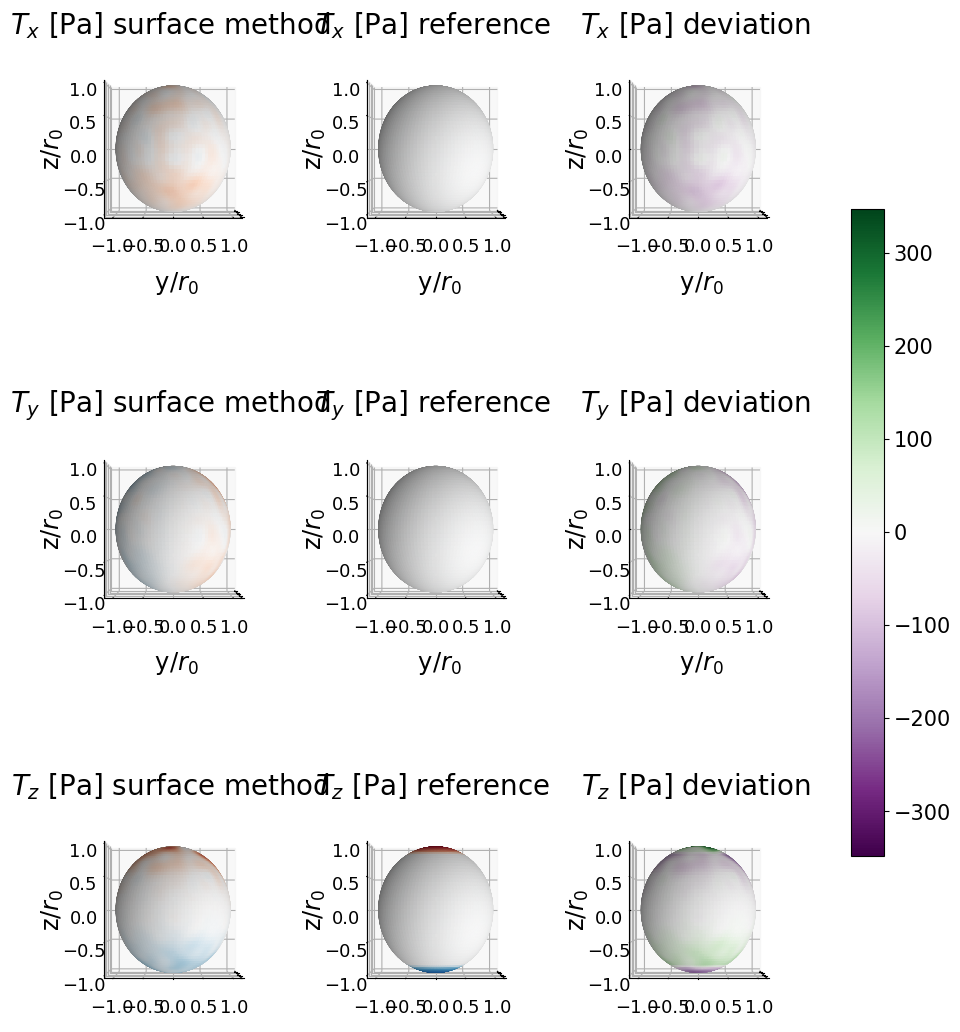

In [ ]:
t_hertz.T_sph=np.zeros_like(t_hertz.T_MF_full_sph)
t_hertz.T_cart=np.zeros_like(t_hertz.T_MF_full_cart)
t_hertz.plot_T_3D(method_='MF',view='sideyz',samescale='all',coord='cart',xextra=0,yextra=0)